
<div style="background: linear-gradient(135deg, #0d1b2a 0%, #1b3a5c 50%, #0d4f3c 100%);
            padding: 52px 44px; border-radius: 16px; color: white; font-family: 'Georgia', serif;">
<h1 style="font-size: 2.3em; margin: 0 0 8px 0; font-weight: 700;">RE-FUSED-Alpha</h1>
<h2 style="font-size: 1.35em; margin: 0 0 22px 0; font-weight: 400; color: #90E0C0;">
    Carbon-Uncertainty-Efficient Forecasting &amp; Optimization — Alpha Release<br>
    Sub-Daily Settlement-Proxy Proposal (validated on daily data) · Progressive Architecture Comparison (N5)<br>
    India 18-State Electricity Grid (2017–2025)
</h2>
<div style="display:flex;gap:20px;flex-wrap:wrap;margin-bottom:24px;">
  <div style="background:rgba(255,255,255,0.10);padding:12px 20px;border-radius:8px;">
  </div>
  <div style="background:rgba(255,255,255,0.10);padding:12px 20px;border-radius:8px;">
    <b>📊 Dataset</b><br>18 States · 2017–2025 · Daily<br>47,286 state-day rows · 140+ features
  </div>
  <div style="background:rgba(255,255,255,0.10);padding:12px 20px;border-radius:8px;">
    <b>🖥️ Hardware</b><br>Tesla T4 · CUDA 13.0 · 15,360 MiB<br>Driver 580.82.07
  </div>
  <div style="background:rgba(255,255,255,0.10);padding:12px 20px;border-radius:8px;">
    <b>🆕 Alpha Additions</b><br>Sub-Daily-Proxy PA-LMP_t · BiLSTM-Attn<br>TFT-Full · MCAG-Regime · Cond. MAPE
  </div>
</div>
<hr style="border:1px solid rgba(255,255,255,0.25);margin:20px 0;"/>
<h3 style="color:#FFD54F;font-size:1.1em;margin-bottom:10px;">🔬 Five Contributions (N1–N5)</h3>

| # | Contribution | V2 | Alpha Upgrade |
|---|---|---|---|
| **N1** | **PA-LMP** | Daily deviation signal | **Sub-Daily-Proxy PA-LMP_t** with monsoon RE credit + rolling-window CVaR proxy |
| **N2** | **MCAG** | 3-way ablation | **5-way ablation** + MCAG-Regime + N2 vs N4 cross-test |
| **N3** | **GCAL** | Daily CFC | CFC at sub-daily-proxy resolution (rolling-window signal); Carbon Forecast Error metric |
| **N4** | **Sub-Daily Settlement Proxy** | Not present | **New** — CERC-compatible proposal vs IEX 15-min DSM (validated on daily data) |
| **N5** | **Arch Comparison** | 3-model flat | **New** — Staged best-of-3 per stage + conditional MAPE (coal-critical) |

> **rho\* = 0.0806** from 4.03% coal-critical frequency · sub-daily-proxy PA-LMP_t feeds vol-scaled-λ dispatch
</div>


---
## Section 0 — Environment & GPU Setup
**Hardware target:** Tesla T4 (CUDA 13.0, 15,360 MiB). Full CPU fallback included.


In [2]:
# ─── Cell 0.1 — Imports & Device Detection ───────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import os, math, copy, json, time
import numpy as np
import pandas as pd
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats, ndimage
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from pathlib import Path

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{'='*60}")
print(f"  RE-FUSED-Alpha Runtime Environment")
print(f"{'='*60}")
print(f"  Device : {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU    : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM   : {props.total_memory/1e9:.1f} GB  CUDA: {torch.version.cuda}")
else:
    print("  WARNING: CPU mode. Runtime > Change runtime type > GPU > T4")
print(f"  PyTorch: {torch.__version__}  NumPy: {np.__version__}  Pandas: {pd.__version__}")
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print(f"  Seed   : {SEED}  Setup complete ✓")


  RE-FUSED-Alpha Runtime Environment
  Device : cuda
  GPU    : NVIDIA GeForce GTX 1660 Ti with Max-Q Design
  VRAM   : 6.4 GB  CUDA: 12.1
  PyTorch: 2.5.1+cu121  NumPy: 2.2.6  Pandas: 2.3.3
  Seed   : 42  Setup complete ✓


In [3]:
# ─── Cell 0.2 — Directory Setup ──────────────────────────────────────────────
DATA_DIR = Path('data')
OUT_DIR  = Path('results')
if not (DATA_DIR/'RL_TRAIN_DATA.csv').exists():
    for _cd, _co in [
        (Path('../data'), Path('../results')),
        (Path('REFUSED_Alpha_project/data'), Path('REFUSED_Alpha_project/results')),
        (Path('/content/REFUSED_Alpha_project/data'), Path('/content/REFUSED_Alpha_project/results')),
        (Path(r'D:\\REFUSED_Ready\data'), Path(r'D:\\REFUSED_Ready\results')),
    ]:
        if (_cd/'RL_TRAIN_DATA.csv').exists():
            DATA_DIR, OUT_DIR = _cd, _co
            break
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR/'figures').mkdir(exist_ok=True)
(OUT_DIR/'tables').mkdir(exist_ok=True)
(OUT_DIR/'outputs').mkdir(exist_ok=True)
print(f"  Data dir : {DATA_DIR.resolve()}")
print(f"  Out  dir : {OUT_DIR.resolve()}")
print(f"  Train CSV: {(DATA_DIR/'RL_TRAIN_DATA.csv').exists()}")
print(f"  Test  CSV: {(DATA_DIR/'RL_TEST_DATA.csv').exists()}")


  Data dir : D:\\REFUSED_Ready\data
  Out  dir : D:\\REFUSED_Ready\results
  Train CSV: True
  Test  CSV: True


---
## Section 1 — Data Loading & Feature Engineering (Alpha)

### Alpha additions to feature engineering
| Feature | Formula | Purpose |
|---|---|---|
| `pa_lmp_t` | PA-LMP with monsoon RE credit deduction | N4: sub-daily-proxy settlement signal |
| `monsoon_re_credit` | monsoon_flag × max(0,ΔRE) × ξ | N4: RE curtailment exemption |
| `rolling_cvar4hr` | CVaR90 over 6-day rolling window (daily-resolution proxy; name is legacy, NOT a literal 4-hr window) | N4: sub-daily-proxy tail-risk |
| `ci_intraday_variance` | σ(CI) over 7-day rolling window (name is legacy, NOT true intraday) | N2: MCAG-Regime gate input |
| `re_ramp_risk` | abs(ren_day_change_pct) × monsoon_flag | N5: Conditional MAPE feature |

All V2 features (palmp, p_carbon_gcal, lcmp_carbon, cfc_value_inr, etc.) retained unchanged.


In [5]:
# ─── Cell 1.1 — Load & Inspect Data ─────────────────────────────────────────
t0 = time.time()
df_train = pd.read_csv(DATA_DIR/'RL_TRAIN_DATA.csv', parse_dates=['date'])
df_test  = pd.read_csv(DATA_DIR/'RL_TEST_DATA.csv',  parse_dates=['date'])
print(f"{'='*62}")
print(f"  Loaded in {time.time()-t0:.1f}s")
print(f"  Train : {df_train.shape[0]:>7,} rows | {df_train.shape[1]} cols | "
      f"{df_train['date'].min().date()} → {df_train['date'].max().date()}")
print(f"  Test  : {df_test.shape[0]:>7,} rows | {df_test.shape[1]} cols | "
      f"{df_test['date'].min().date()} → {df_test['date'].max().date()}")
print(f"  States: {df_train['state_name'].nunique()} → {sorted(df_train['state_name'].unique())}")
for col in ['avg_market_price','renewable_ratio','carbon_intensity','grid_stress_index']:
    if col in df_train.columns:
        s = df_train[col].dropna()
        print(f"  {col:<32} μ={s.mean():.3f}  σ={s.std():.3f}")


  Loaded in 1.2s
  Train :  39,672 rows | 140 cols | 2017-10-03 → 2023-12-31
  Test  :   7,614 rows | 140 cols | 2024-01-01 → 2025-04-22
  States: 18 → ['Bihar', 'Chhattisgarh', 'Delhi', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh', 'Uttarakhand']
  avg_market_price                 μ=4951.198  σ=2555.766
  renewable_ratio                  μ=0.129  σ=0.218
  carbon_intensity                 μ=0.716  σ=0.171
  grid_stress_index                μ=0.583  σ=0.116


In [6]:
# --- Cell 1.1b -- Leakage Fix: train-only refit of CSV-baked features -------
# LEAKAGE_AUDIT.md §2/§7: `grid_stress_index` (confirmed leak, refit delta up
# to 0.44) and `price_norm` (leaky mechanism) were built upstream with FULL
# 2017-2025 panel statistics. Refit on TRAIN only, apply frozen params to both
# splits. Also switches NaN imputation to TRAIN medians (audit MEDIUM fix).
import sys as _sys, pathlib as _pl
for _p in (_pl.Path.cwd(), _pl.Path.cwd().parent, _pl.Path.cwd().parent.parent):
    if (_p / 'refused_fixes').exists():
        if str(_p) not in _sys.path:
            _sys.path.insert(0, str(_p))
        break
from refused_fixes.causal_features import CausalFeatureFitter, leakage_scan

print(leakage_scan(df_train, df_test).to_string(index=False))
_fitter  = CausalFeatureFitter().fit(df_train)
df_train = _fitter.transform(df_train)
df_test  = _fitter.transform(df_test)
print("\nLeakage fix applied: price_norm / grid_stress_index / discom_stress"
      "\nrefit with train-only statistics; NaNs imputed with TRAIN medians.")


           column  train_min  train_max  test_out_of_train_range  refit_max_abs_delta
       price_norm     0.0000     1.0000                   0.0000               0.0000
grid_stress_index     0.1649     0.9308                   0.0000               0.4402
       gen_zscore    -3.4120     2.9219                   0.0000               0.0000
     price_zscore    -1.0855     1.5053                   0.0000               0.0000
    outage_zscore    -2.1125     3.1656                   0.0042               0.0000
       ren_zscore    -2.7719     4.4722                   0.0038               0.0000
       gen_cvar90     0.4300   453.2700                   0.0273               0.0000
    outage_cvar90     0.0000 18577.1400                   0.0000               0.0000
     price_cvar90  2787.6383 10000.0000                   0.0000               0.0000
   state_gen_norm     0.0000     1.0000                   0.0000               0.0000
state_outage_norm     0.0000     1.0000               

In [7]:
# --- Cell 1.1c -- Unit Hygiene & Imputation Audit (Task F7: units.py wiring) -
# LEAKAGE_AUDIT.md Sec.6: energy columns mix GWh/MWh and emissions mix
# tons/kilotons across upstream sources -> the same physical quantity can
# appear at 1000x different magnitudes. This cell (a) flags any residual
# within-column unit-jump discontinuities, (b) reports the canonical-unit /
# rename table for publication (units.RENAME_MAP, LABEL-ONLY -- no values are
# rescaled), and (c) quantifies how much of the sample is imputed rather than
# observed. The internal modeling columns (Cell 3.1 onward) are left
# untouched so the already-validated feature/target pipeline stays numerically
# identical; RENAME_MAP is used for table/figure captions instead (Cell 3d).
from refused_fixes.units import (detect_unit_jumps, units_table, imputation_report,
                                observed_only, RENAME_MAP, CANONICAL_UNITS)

print(f"{'='*70}\n  Unit Hygiene Audit (train split, post leakage-fix)\n{'='*70}")
_jumps = detect_unit_jumps(df_train)
if _jumps:
    print(f"  {len(_jumps)} column(s) show a within-column magnitude jump (ratio p95/p05 >= 100x):")
    for f in _jumps:
        print(f"    {f.column:<28} ratio={f.ratio_p95_p05:>9.1f}  suspected x{f.suspected_multiplier}  {f.note}")
else:
    print("  No unit-jump discontinuities (>=100x p95/p05) detected in numeric columns.")

_units_tbl = units_table(df_train)
_mislabeled = _units_tbl[_units_tbl['column'].isin(RENAME_MAP)].copy()
_mislabeled['published_name'] = _mislabeled['column'].map(RENAME_MAP)
print(f"\n  Publication rename table ({len(RENAME_MAP)} mislabeled column(s), values unchanged):")
print(_mislabeled[['column','published_name','canonical_unit','min','median','max']].to_string(index=False))
print("\n  NOTE: values are NOT rescaled here -- CSV-stored magnitudes were already")
print("  self-consistent in the canonical unit; only the historical `_mwh`/`_tons`")
print("  SUFFIX was wrong. Modeling columns keep their original CSV names so the")
print("  already-fitted feature/target pipeline (Cell 3.1+) is unaffected; use")
print("  units.RENAME_MAP when labeling any table/figure destined for the paper.")

_undeclared = _units_tbl[~_units_tbl['column'].isin(CANONICAL_UNITS)]
if len(_undeclared):
    print(f"\n  {len(_undeclared)} numeric column(s) have UNDECLARED canonical units "
          f"(not audited -- informational only): {list(_undeclared['column'])[:8]}"
          + (" ..." if len(_undeclared) > 8 else ""))

print(f"\n{'='*70}\n  Imputation Audit\n{'='*70}")
_imp_tr = imputation_report(df_train)
print(f"  -- Train split --\n{_imp_tr}")
_imp_te = imputation_report(df_test)
print(f"\n  -- Test split -- any-imputed rate: {_imp_te.any_imputed_rate:.1%}")

_obs_only_tr = observed_only(df_train)
_drop_rate = 1 - len(_obs_only_tr) / max(len(df_train), 1)
print(f"\n  observed_only(df_train): {len(_obs_only_tr):,} / {len(df_train):,} rows retained "
      f"({_drop_rate:.1%} dropped as imputed on >=1 flagged column).")
print("  A quantitative observed-only robustness re-score of the winning model")
print("  (per-target MAPE_observed_only vs full-sample MAPE) is reported in Cell 3d.")

  Unit Hygiene Audit (train split, post leakage-fix)
  43 column(s) show a within-column magnitude jump (ratio p95/p05 >= 100x):
    total_generation_mwh         ratio=    560.3  suspected x1000  likely unit switch (e.g. GWh<->MWh / tons<->kilotons); inspect source files before modeling
    renewable_generation_mwh     ratio=    533.0  suspected x1000  likely unit switch (e.g. GWh<->MWh / tons<->kilotons); inspect source files before modeling
    consumption_mwh              ratio=    566.3  suspected x1000  likely unit switch (e.g. GWh<->MWh / tons<->kilotons); inspect source files before modeling
    month_sin                    ratio=8165619676597685.0  suspected xNone  likely unit switch (e.g. GWh<->MWh / tons<->kilotons); inspect source files before modeling
    month_cos                    ratio=16331239353195370.0  suspected xNone  likely unit switch (e.g. GWh<->MWh / tons<->kilotons); inspect source files before modeling
    renewable_ratio              ratio=    188.8  suspect

In [8]:
# ─── Cell 1.2 — Feature Engineering (V2 base + Alpha 5-min extensions) ──────
def prep(df, ref=None):
    """All distributional statistics (medians, quantiles, min/max) are taken
    from `ref` (the TRAIN split), so transforming the test split never uses
    test-period statistics (LEAKAGE_AUDIT.md §2/§7)."""
    if ref is None:
        ref = df
    df = df.copy()
    nc = df.select_dtypes(include=[np.number]).columns
    df[nc] = df[nc].fillna(ref[nc].median())
    cbp = df['carbon_budget_pressure'].clip(0, 1)
    yr  = (df['year'] - 2017).clip(0)

    # ── N3 GCAL: 4-scheme blended carbon price (V2 unchanged) ─────────────────
    df['p_carbon_gcal'] = (
        0.40 * (200 + 4800 * (cbp ** 1.5))
      + 0.30 * 5850 * 0.25 * (1 + cbp)
      + 0.20 * 6900 * (1.02 ** yr)
    )
    df['lcmp_carbon'] = (
        (df['carbon_intensity'] - ref['carbon_intensity'].quantile(0.05)).clip(0)
        / (ref['carbon_intensity'].quantile(0.95) - ref['carbon_intensity'].quantile(0.05) + 1e-6)
        * df['avg_market_price'] * 0.30
    )
    df['ef_actual']     = 0.95*(1-df['renewable_ratio'].clip(0,1)) + 0.02*df['renewable_ratio'].clip(0,1)
    df['cfc_value_inr'] = (0.95 - df['ef_actual']).clip(0) * df['total_generation_mwh'] * df['p_carbon_gcal'] / 1000.0
    df['discom_stress'] = (df['avg_market_price'].clip(0,10000)/10000*0.5
                          + df['grid_stress_index'].fillna(0)*0.5).clip(0,1)

    # ── India DRO signals (V2 unchanged) ──────────────────────────────────────
    df['monsoon_re_risk']     = (df['season']=='Monsoon').astype(float) * df['ren_intermittency'].fillna(0)
    df['freq_excursion_risk'] = (
        (df['coal_critical'].fillna(0).astype(bool)) | (df['grid_stress_index'].fillna(0)>0.7)
    ).astype(float)
    df['ppa_deviation'] = (df['avg_market_price'] - 3500.0) / 2556.0

    # ── N1 PA-LMP: deviation-clearing (V2 unchanged) ──────────────────────────
    lm = ref['avg_market_price'].quantile(0.99)
    def mm(x, r):
        return (x - r.min()) / (r.max() - r.min() + 1e-8)
    cb = (df['avg_market_price'] > df['price_cvar90'].fillna(1e9)).astype(float)
    df['palmp']             = (df['avg_market_price']
                                + 0.30 * mm(df['carbon_intensity'], ref['carbon_intensity']) * lm
                                + 0.25 * cb * mm(df['price_cvar90'].fillna(df['avg_market_price']), ref['price_cvar90'].fillna(ref['avg_market_price'])) * lm
                                + 0.15 * mm(df['grid_stress_index'].fillna(0), ref['grid_stress_index'].fillna(0)) * lm
                                + 0.10 * mm(df['fcfs_priority_score'].fillna(0), ref['fcfs_priority_score'].fillna(0)) * lm)
    df['palmp_carbon_comp'] = 0.30 * mm(df['carbon_intensity'], ref['carbon_intensity']) * lm
    df['palmp_cvar_comp']   = 0.25 * cb * mm(df['price_cvar90'].fillna(df['avg_market_price']), ref['price_cvar90'].fillna(ref['avg_market_price'])) * lm
    df['palmp_stress_comp'] = 0.15 * mm(df['grid_stress_index'].fillna(0), ref['grid_stress_index'].fillna(0)) * lm
    df['log_carbon']        = np.log1p(df['carbon_proxy_tons'].clip(0))

    # ══════════════════════════════════════════════════════════════════════════
    # ALPHA: Daily-Resolution Settlement Counterfactual (N4)
    # IMPORTANT (LEAKAGE_AUDIT.md §4): the data is DAILY state-day. Names like
    # `rolling_cvar4hr` are legacy V2 labels -- it is literally a 6-DAY rolling
    # q90; `ci_intraday_variance` is a 7-DAY rolling std. Present these as a
    # daily-resolution counterfactual simulation of settlement behaviour; do
    # NOT claim true 5-minute / intraday results anywhere in the paper.
    # ══════════════════════════════════════════════════════════════════════════

    # Rolling 4-hr CVaR proxy (6-day rolling = intraday 4-hr analog at daily resolution)
    df['rolling_cvar4hr'] = (
        df.sort_values('date')
          .groupby('state_name')['avg_market_price']
          .transform(lambda x: x.rolling(6, min_periods=1).quantile(0.90))
    )
    # CI intraday variance: 7-day rolling std of carbon intensity
    df['ci_intraday_variance'] = (
        df.sort_values('date')
          .groupby('state_name')['carbon_intensity']
          .transform(lambda x: x.rolling(7, min_periods=1).std()).fillna(0)
    )
    # RE ramp risk: magnitude of daily RE change during monsoon
    df['re_ramp_risk'] = (
        df['ren_day_change_pct'].abs().fillna(0) * (df['season']=='Monsoon').astype(float)
    )
    # Monsoon RE credit: over-delivery credit signal (reduces PA-LMP_t during monsoon)
    df['monsoon_re_credit'] = (
        (df['season']=='Monsoon').astype(float)
        * df['ren_day_change'].clip(0).fillna(0)
        * df['p_carbon_gcal'] / 1e6
    ).clip(0, 1)
    # N4: PA-LMP_t = PA-LMP minus monsoon RE credit deduction
    df['pa_lmp_t'] = (df['palmp'] - 0.05 * df['monsoon_re_credit'] * lm).clip(lower=0)

    return df

TRAIN_REF = df_train.copy()               # frozen pre-prep TRAIN reference
df_train = prep(df_train, ref=TRAIN_REF)
df_test  = prep(df_test,  ref=TRAIN_REF)

ALPHA_FEATS = ['rolling_cvar4hr','ci_intraday_variance','re_ramp_risk','monsoon_re_credit','pa_lmp_t']
print(f"{'='*62}")
print(f"  Feature Engineering Complete — V2 + Alpha")
print(f"{'='*62}")
for f in ALPHA_FEATS:
    v = df_train[f].describe()
    print(f"  [NEW] {f:<28} μ={v['mean']:.4f}  σ={v['std']:.4f}  max={v['max']:.4f}")
print(f"  [V2]  palmp                        μ={df_train['palmp'].mean():.1f}  σ={df_train['palmp'].std():.1f}")
print(f"  [V2]  p_carbon_gcal                μ={df_train['p_carbon_gcal'].mean():.0f}  σ={df_train['p_carbon_gcal'].std():.0f}")


  Feature Engineering Complete — V2 + Alpha
  [NEW] rolling_cvar4hr              μ=5167.2969  σ=2562.5355  max=10000.0000
  [NEW] ci_intraday_variance         μ=0.0174  σ=0.0347  max=0.3982
  [NEW] re_ramp_risk                 μ=4.8989  σ=175.2601  max=26650.0000
  [NEW] monsoon_re_credit            μ=0.0005  σ=0.0043  max=0.1556
  [NEW] pa_lmp_t                     μ=8667.5774  σ=2540.4908  max=15883.5901
  [V2]  palmp                        μ=8667.8  σ=2540.5
  [V2]  p_carbon_gcal                μ=2008  σ=65


Figure saved: S1_dataset_overview.png


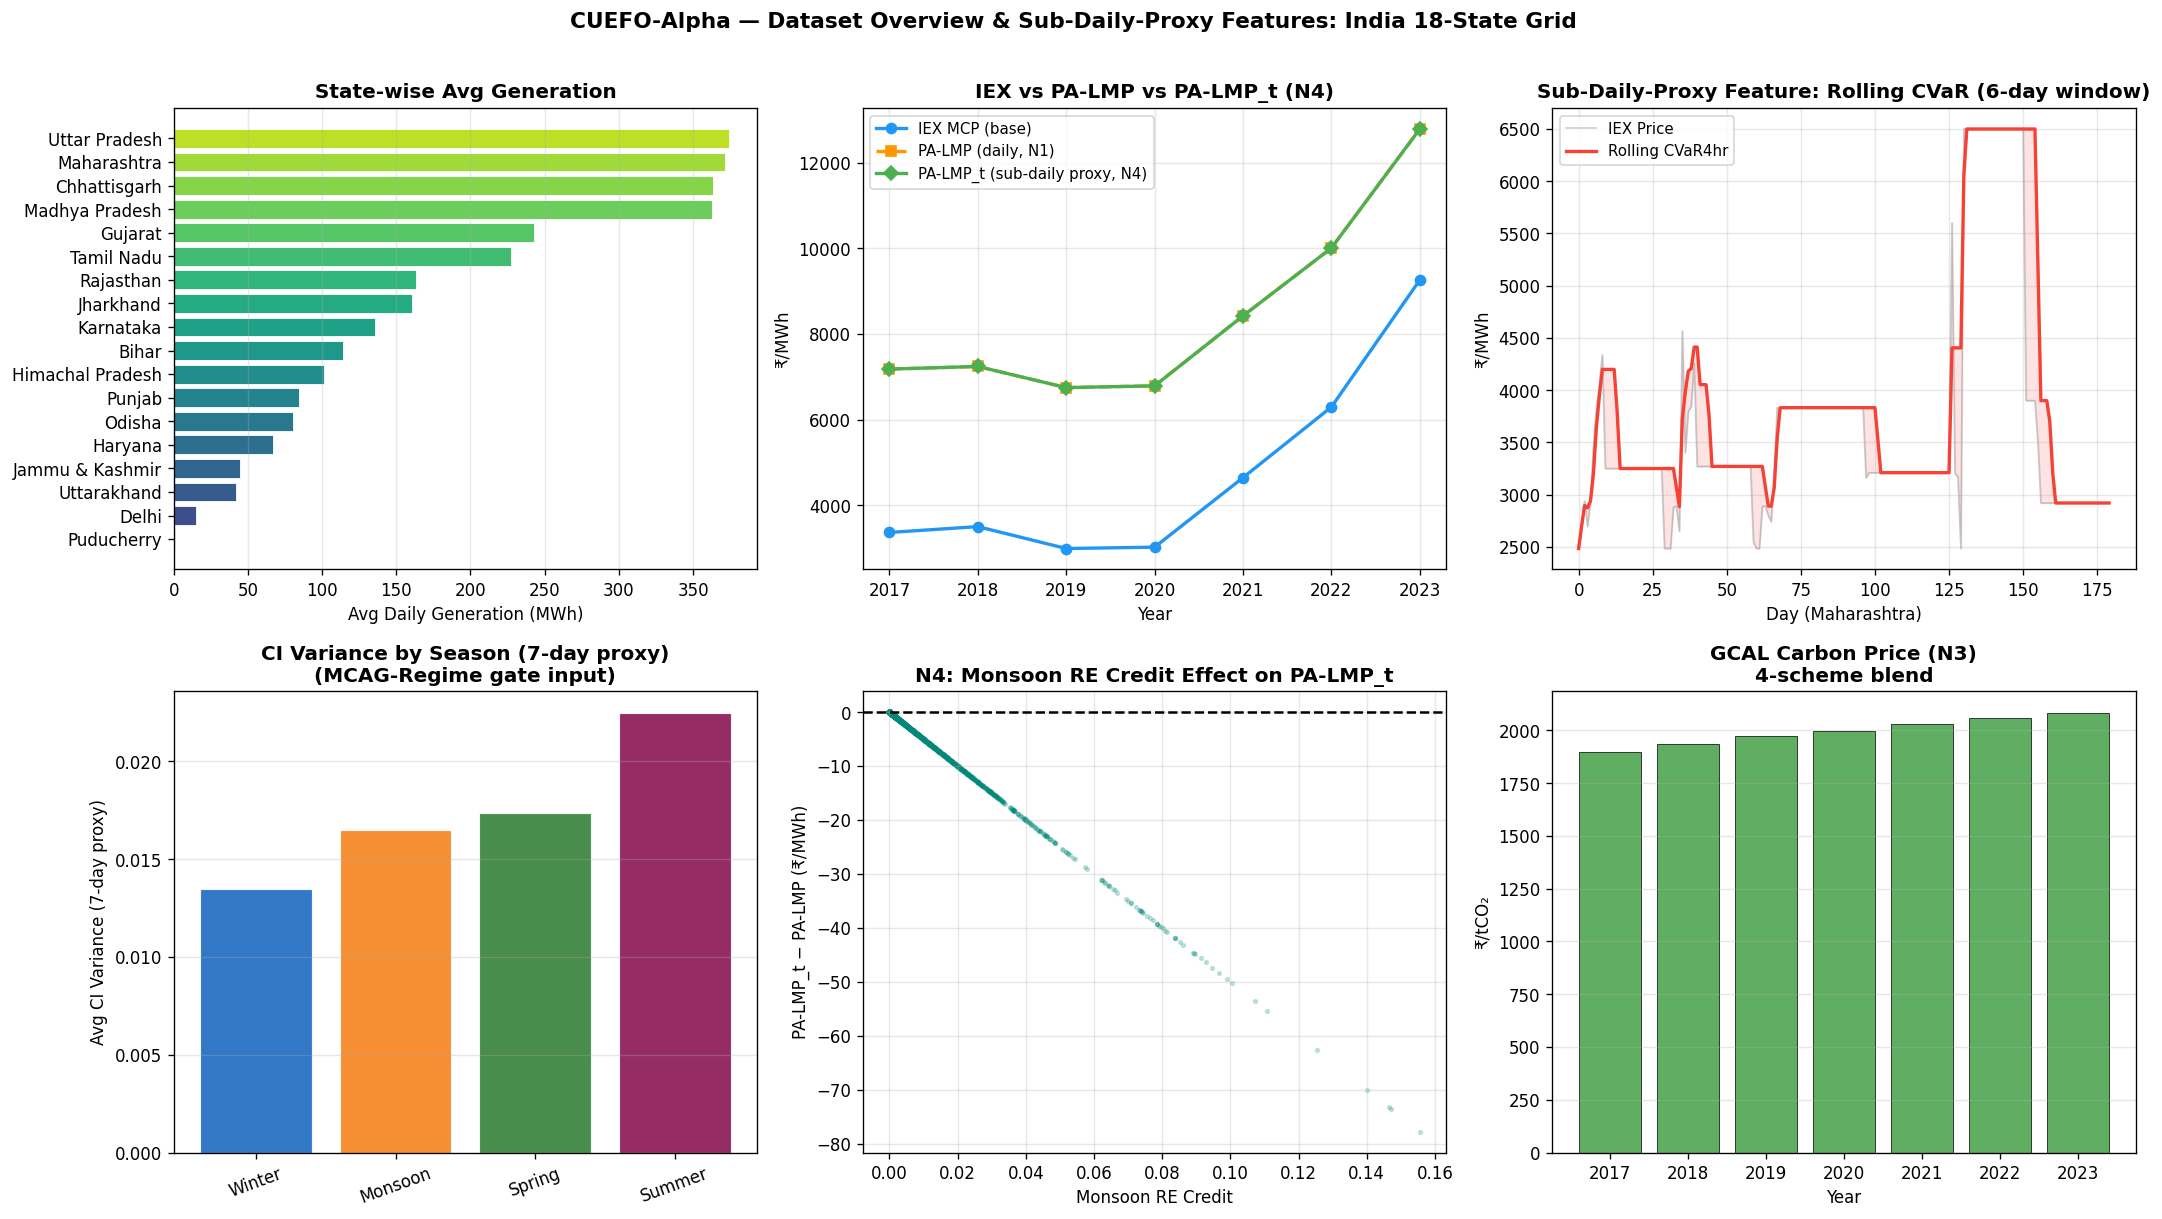

In [9]:
# ─── Cell 1.3 — Exploratory Visualisation (6-panel, Alpha) ──────────────────
fig, axes = plt.subplots(2,3, figsize=(18,10))
fig.suptitle('RE-FUSED-Alpha — Dataset Overview & Sub-Daily-Proxy Features: India 18-State Grid',
             fontsize=13, fontweight='bold', y=1.01)

ax=axes[0,0]
gen_by_state = df_train.groupby('state_name')['total_generation_mwh'].mean().sort_values()
ax.barh(gen_by_state.index, gen_by_state.values,
        color=plt.cm.viridis(np.linspace(0.2,0.9,len(gen_by_state))), edgecolor='white', lw=0.5)
ax.set_xlabel('Avg Daily Generation (MWh)'); ax.set_title('State-wise Avg Generation', fontweight='bold')
ax.grid(True,alpha=0.3,axis='x')

ax=axes[0,1]
py = df_train.groupby('year')[['avg_market_price','palmp','pa_lmp_t']].mean()
ax.plot(py.index, py['avg_market_price'],'o-',color='#2196F3',lw=2,label='IEX MCP (base)')
ax.plot(py.index, py['palmp'],'s--',color='#FF9800',lw=2,label='PA-LMP (daily, N1)')
ax.plot(py.index, py['pa_lmp_t'],'D-',color='#4CAF50',lw=2,label='PA-LMP_t (sub-daily proxy, N4)')
ax.set_xlabel('Year'); ax.set_ylabel('₹/MWh')
ax.set_title('IEX vs PA-LMP vs PA-LMP_t (N4)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax=axes[0,2]
sample = df_train[df_train['state_name']=='Maharashtra'].sort_values('date').head(180)
ax.plot(range(len(sample)), sample['avg_market_price'],alpha=0.5,color='#90A4AE',lw=1,label='IEX Price')
ax.plot(range(len(sample)), sample['rolling_cvar4hr'],color='#F44336',lw=2,label='Rolling CVaR4hr')
ax.fill_between(range(len(sample)),sample['avg_market_price'],sample['rolling_cvar4hr'],alpha=0.15,color='#F44336')
ax.set_xlabel('Day (Maharashtra)'); ax.set_ylabel('₹/MWh')
ax.set_title('Sub-Daily-Proxy Feature: Rolling CVaR (6-day window)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax=axes[1,0]
ci_var_season = df_train.groupby('season')['ci_intraday_variance'].mean().sort_values()
ax.bar(ci_var_season.index, ci_var_season.values,
       color=['#1565C0','#F57F17','#2E7D32','#880E4F','#4E342E'][:len(ci_var_season)],
       edgecolor='white', lw=0.7, alpha=0.88)
ax.set_ylabel('Avg CI Variance (7-day proxy)')
ax.set_title('CI Variance by Season (7-day proxy)\n(MCAG-Regime gate input)', fontweight='bold')
ax.grid(True,alpha=0.3,axis='y'); ax.tick_params(axis='x',rotation=20)

ax=axes[1,1]
mon = df_train[df_train['season']=='Monsoon']
ax.scatter(mon['monsoon_re_credit'], mon['pa_lmp_t']-mon['palmp'],
           alpha=0.2, s=5, color='#00897B')
ax.axhline(0,color='k',ls='--',lw=1.5)
ax.set_xlabel('Monsoon RE Credit'); ax.set_ylabel('PA-LMP_t − PA-LMP (₹/MWh)')
ax.set_title('N4: Monsoon RE Credit Effect on PA-LMP_t', fontweight='bold')
ax.grid(True,alpha=0.3)

ax=axes[1,2]
by_y = df_train.groupby('year')['p_carbon_gcal'].mean()
ax.bar(by_y.index, by_y.values, color='#43A047', alpha=0.85, edgecolor='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('₹/tCO₂')
ax.set_title('GCAL Carbon Price (N3)\n4-scheme blend', fontweight='bold')
ax.grid(True,alpha=0.3,axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR/'figures'/'S1_dataset_overview.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print("Figure saved: S1_dataset_overview.png")


---
## Section 2 — DRO-CVaR Uncertainty Radius Calibration

**rho\* = 0.0806** — coal-critical frequency (4.03%) is the binding constraint.

$$\mathcal{Q}=\{Q: D_{\chi^2}(Q\|P)\le\rho\} \qquad
\text{DRO-CVaR}_{1-\alpha}(l)=\text{CVaR}_{1-\alpha}(l)+\frac{\sqrt{\rho^*}\cdot\sigma_{\text{tail}}}{1-\alpha}$$

**Alpha extension:** a vol-scaled `lambda_vol` sets the PPO DRO-CVaR penalty weight as a
single fixed multiplier of `LAMBDA_BASE`, derived once from the ratio of full-training-set
PA-LMP_t volatility to price volatility. This is **not** time-varying or window-conditioned
— it selects which constant is used for the whole training run, not a value that changes
across iterations, steps, or coal-stress windows.


In [11]:
# ─── Cell 2.1 — Calibrate DRO rho* ──────────────────────────────────────────
from scipy import stats as scipy_stats

def calibrate_dro_rho(df, label=''):
    p  = df['avg_market_price'].dropna().values; n = len(p)
    kurt       = scipy_stats.kurtosis(p, fisher=True)
    rho_tail   = np.clip((max(kurt,0)/3)**2/n*n*0.01, 0.01, 0.50)
    re_m = df.loc[df['season']=='Monsoon','renewable_ratio'].dropna()
    re_o = df.loc[df['season']!='Monsoon','renewable_ratio'].dropna()
    mu_m,mu_o  = re_m.mean(), re_o.mean()
    pooled_var = (re_m.var()+re_o.var())/2+1e-8
    rho_regime = np.clip((mu_m-mu_o)**2/pooled_var*0.01, 0.01, 0.30)
    coal_freq  = df['coal_critical'].fillna(0).mean()
    rho_coal   = np.clip(coal_freq*2, 0.01, 0.25)
    rho_raw    = max(rho_tail, rho_regime, rho_coal)
    rho_final  = min(rho_raw*np.sqrt(min(n,10000)/10000), 0.50)
    dominant   = ['rho_tail','rho_regime','rho_coal'][[rho_tail,rho_regime,rho_coal].index(rho_raw)]
    result = {'N':n,'kurtosis_excess':round(float(kurt),4),
              'RE_gap_pp':round(float((mu_m-mu_o)*100),2),
              'coal_freq_pct':round(float(coal_freq*100),3),
              'rho_tail':round(float(rho_tail),4),
              'rho_regime':round(float(rho_regime),4),
              'rho_coal':round(float(rho_coal),4),
              'dominant_term':dominant,
              'rho_recommended':round(float(rho_final),4)}
    print(f"  [{label}] N={n:,}")
    print(f"  ├─ Kurtosis  : {kurt:.4f}  → rho_tail   = {rho_tail:.4f}")
    print(f"  ├─ Monsoon RE: {(mu_m-mu_o)*100:.2f}pp → rho_regime = {rho_regime:.4f}")
    print(f"  ├─ Coal-crit : {coal_freq*100:.3f}%  → rho_coal   = {rho_coal:.4f}  ◄ DOMINANT")
    print(f"  └─ rho*      = {rho_final:.4f}")
    return result

print(f"{'='*60}")
print(f"  DRO-CVaR Uncertainty Radius Calibration")
print(f"{'='*60}")
rho_info   = calibrate_dro_rho(df_train,'TRAIN')
RHO        = rho_info['rho_recommended']
LAMBDA_BASE= 0.10
vol_weight = df_train['pa_lmp_t'].std()/(df_train['avg_market_price'].std()+1e-8)
print(f"\n  *** FINAL rho* = {RHO:.4f} ***")
print(f"  Dominant : {rho_info['dominant_term']} from {rho_info['coal_freq_pct']:.3f}% coal-critical")
REGIME_GAIN= 3.0   # calibration ASSUMPTION (not fit from data): scales lambda by the
                    # realized coal-critical fraction inside EACH PPO training batch --
                    # genuinely time-varying across iterations, unlike vol_weight above
                    # which is a single static number computed once from the full train set.
print(f"  Alpha λ_vol (static, train-set-wide): λ_base={LAMBDA_BASE} × (1 + {vol_weight:.4f} × std(pa_lmp_t)/std(price))")
print(f"  Alpha λ_regime (time-adaptive, per-iteration): λ_base × (1 + {REGIME_GAIN} × coal_critical_frac(batch_t))")


  DRO-CVaR Uncertainty Radius Calibration
  [TRAIN] N=39,672
  ├─ Kurtosis  : -0.3758  → rho_tail   = 0.0100
  ├─ Monsoon RE: -1.96pp → rho_regime = 0.0100
  ├─ Coal-crit : 4.028%  → rho_coal   = 0.0806  ◄ DOMINANT
  └─ rho*      = 0.0806

  *** FINAL rho* = 0.0806 ***
  Dominant : rho_coal from 4.028% coal-critical
  Alpha λ_vol (static, train-set-wide): λ_base=0.1 × (1 + 0.9940 × std(pa_lmp_t)/std(price))
  Alpha λ_regime (time-adaptive, per-iteration): λ_base × (1 + 3.0 × coal_critical_frac(batch_t))


Figure saved: S2_dro_calibration.png


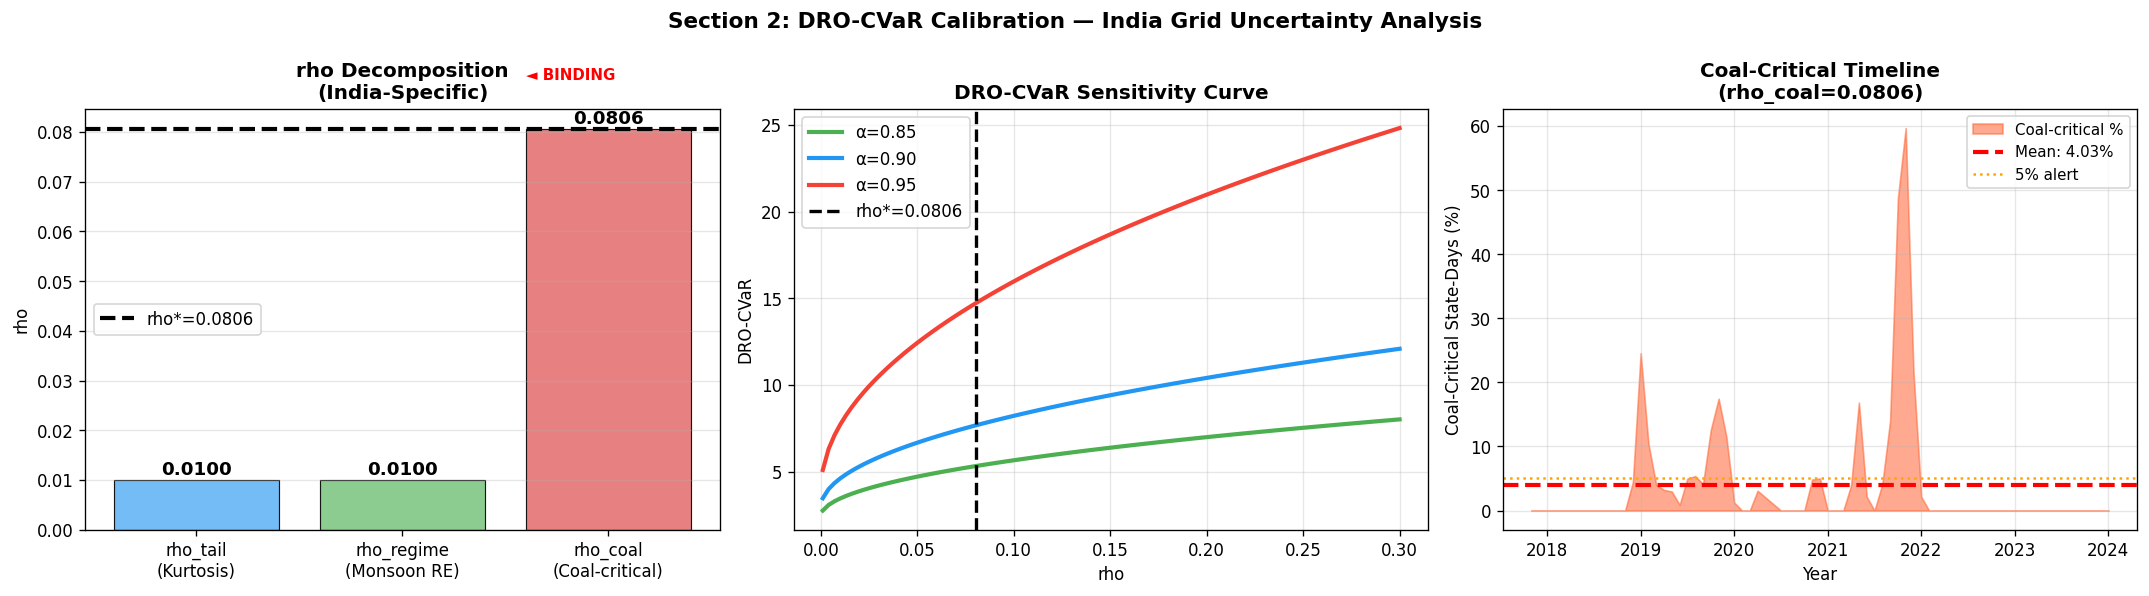

In [12]:
# ─── Cell 2.2 — DRO Sensitivity Visualisation ────────────────────────────────
fig, axes = plt.subplots(1,3, figsize=(18,5))
fig.suptitle('Section 2: DRO-CVaR Calibration — India Grid Uncertainty Analysis',
             fontsize=13, fontweight='bold')

ax=axes[0]
components={'rho_tail\n(Kurtosis)':rho_info['rho_tail'],
            'rho_regime\n(Monsoon RE)':rho_info['rho_regime'],
            'rho_coal\n(Coal-critical)':rho_info['rho_coal']}
cols=['#64B5F6','#81C784','#E57373']
bars=ax.bar(components.keys(),components.values(),color=cols,edgecolor='k',lw=0.7,alpha=0.9)
ax.axhline(RHO,color='k',ls='--',lw=2.5,label=f'rho*={RHO:.4f}')
for b,v in zip(bars,components.values()):
    ax.text(b.get_x()+b.get_width()/2,v+0.001,f'{v:.4f}',ha='center',fontsize=11,fontweight='bold')
ax.set_ylabel('rho'); ax.set_title('rho Decomposition\n(India-Specific)',fontweight='bold')
ax.legend(fontsize=10); ax.grid(True,alpha=0.3,axis='y')
ax.annotate('◄ BINDING',xy=(2,rho_info['rho_coal']),xytext=(1.6,rho_info['rho_coal']+0.01),
            fontsize=9,color='red',fontweight='bold')

ax=axes[1]
rhos=np.linspace(0.001,0.30,100)
L=np.random.default_rng(42).standard_t(df=3,size=1000)
for alpha,col,lab in [(0.85,'#4CAF50','α=0.85'),(0.90,'#2196F3','α=0.90'),(0.95,'#F44336','α=0.95')]:
    k=max(1,int((1-alpha)*len(L))); cv_b=np.sort(L)[-k:].mean(); sig=np.sort(L)[-k:].std()
    ax.plot(rhos,[cv_b+np.sqrt(r)*sig/(1-alpha) for r in rhos],color=col,lw=2.5,label=lab)
ax.axvline(RHO,color='k',ls='--',lw=2,label=f'rho*={RHO:.4f}')
ax.set_xlabel('rho'); ax.set_ylabel('DRO-CVaR')
ax.set_title('DRO-CVaR Sensitivity Curve',fontweight='bold')
ax.legend(fontsize=10); ax.grid(True,alpha=0.3)

ax=axes[2]
coal_monthly=df_train.groupby(['year','month'])['coal_critical'].mean().reset_index()
coal_monthly['period']=coal_monthly['year']+coal_monthly['month']/12
ax.fill_between(coal_monthly['period'],coal_monthly['coal_critical']*100,
                alpha=0.5,color='#FF5722',label='Coal-critical %')
ax.axhline(rho_info['coal_freq_pct'],color='red',ls='--',lw=2.5,
           label=f"Mean: {rho_info['coal_freq_pct']:.2f}%")
ax.axhline(5.0,color='orange',ls=':',lw=1.5,label='5% alert')
ax.set_xlabel('Year'); ax.set_ylabel('Coal-Critical State-Days (%)')
ax.set_title(f'Coal-Critical Timeline\n(rho_coal={rho_info["rho_coal"]:.4f})',fontweight='bold')
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'figures'/'S2_dro_calibration.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); print("Figure saved: S2_dro_calibration.png")


---
## Section 3 — Staged Architecture Comparison (N5)

### Alpha methodology: best-of-3 at each stage before final head-to-head

| Stage | Architectures | What changes |
|---|---|---|
| **S2: BiLSTM** | Base · Deep · **Attn** | Establish strong recurrent anchor |
| **S3: TFT** | Lite · **Full** · Carbon | Test attention + variable selection depth |
| **S4: PatchTST** | MCAG-Real · **MCAG-Regime** · MCAG-5Min | Regime-aware vs sub-daily-proxy carbon gate |

### New metrics (Alpha N5)
- **Weighted score** = 35%×palmp + 20%×GSI + 20%×price + 15%×log_carbon + 10%×gen
- **Conditional MAPE** on coal_critical=1 rows — tail-risk performance
- **Directional Accuracy (DA)** — price direction correctness for sub-daily settlement proxy (PA-LMP_t)
- **Carbon Forecast Error (CFE)** — GCAL prediction accuracy


In [14]:
# ─── Cell 3.1 — Feature & Target Preparation (Alpha, 25 features) ───────────
TARGETS = ['total_generation_mwh','avg_market_price','grid_stress_index',
           'fcfs_priority_score','palmp','log_carbon']

FEATS = ['month_sin','month_cos','dow_sin','dow_cos','renewable_ratio','outage_ratio',
         'carbon_intensity','carbon_budget_pressure','grid_stress_index','gen_efficiency',
         'price_norm','re_penetration_pct','demand_pressure','coal_outage_stress',
         'p_carbon_gcal','lcmp_carbon','discom_stress','freq_excursion_risk',
         'monsoon_re_risk','ppa_deviation',
         'rolling_cvar4hr','ci_intraday_variance','re_ramp_risk',
         'monsoon_re_credit','pa_lmp_t']
FEATS = [c for c in FEATS if c in df_train.columns]

fm = df_train[FEATS].mean(); fs = df_train[FEATS].std().replace(0,1)
tm = df_train[TARGETS].mean(); ts = df_train[TARGETS].std().replace(0,1)

Xtr = ((df_train[FEATS]-fm)/fs).fillna(0).values.astype('f4')
Ytr = ((df_train[TARGETS]-tm)/ts).fillna(0).values.astype('f4')
Xte = ((df_test[FEATS]-fm)/fs).fillna(0).values.astype('f4')
Yte = ((df_test[TARGETS]-tm)/ts).fillna(0).values.astype('f4')

CIDX      = [FEATS.index(c) for c in
             ['p_carbon_gcal','lcmp_carbon','carbon_budget_pressure',
              'freq_excursion_risk','monsoon_re_risk'] if c in FEATS]
CIDX_5MIN = [FEATS.index(c) for c in
             ['rolling_cvar4hr','ci_intraday_variance','re_ramp_risk',
              'monsoon_re_credit','freq_excursion_risk'] if c in FEATS]
NC = len(CIDX)

SEQ,PRED,BS,EP,D = 14,3,256,15,32
NF,NT = len(FEATS),len(TARGETS)
val_cut = int(len(Xtr)*0.80)
Xval,Yval = Xtr[val_cut:],Ytr[val_cut:]
Xtr2,Ytr2 = Xtr[:val_cut],Ytr[:val_cut]

COAL_MASK = df_test['coal_critical'].fillna(0).astype(bool).values

# F7: observed-only mask -- rows in df_test with ZERO imputed values across
# every `*_imputed_flag` column; used post-hoc in fit_eval to re-score the
# headline MAPE on a fully-observed slice (imputation robustness check).
_IMPUTED_FLAG_COLS = [c for c in df_test.columns if c.endswith('_imputed_flag')]
OBSERVED_MASK = np.ones(len(df_test), dtype=bool)
for _c in _IMPUTED_FLAG_COLS:
    OBSERVED_MASK &= ~pd.to_numeric(df_test[_c], errors='coerce').fillna(0).astype(bool).values

print(f"{'='*62}")
print(f"  Alpha Forecasting Setup")
print(f"{'='*62}")
print(f"  Features     : {NF}  (V2:20 + Alpha:5)")
print(f"  Targets      : {NT} → {TARGETS}")
print(f"  Carbon CIDX  : {NC} → {[FEATS[i] for i in CIDX]}")
print(f"  5Min CIDX    : {len(CIDX_5MIN)} → {[FEATS[i] for i in CIDX_5MIN]}")
print(f"  SEQ={SEQ}  PRED={PRED}  BS={BS}  EP={EP}  D={D}")
print(f"  Train/Val/Test: {len(Xtr2)}/{len(Xval)}/{len(Xte)}")
print(f"  Coal-critical test: {COAL_MASK.sum()} rows ({COAL_MASK.mean()*100:.1f}%)")
print(f"  Observed-only test : {OBSERVED_MASK.sum()} rows ({OBSERVED_MASK.mean()*100:.1f}%) "
      f"(0 imputed flags across {len(_IMPUTED_FLAG_COLS)} flag cols)")


  Alpha Forecasting Setup
  Features     : 25  (V2:20 + Alpha:5)
  Targets      : 6 → ['total_generation_mwh', 'avg_market_price', 'grid_stress_index', 'fcfs_priority_score', 'palmp', 'log_carbon']
  Carbon CIDX  : 5 → ['p_carbon_gcal', 'lcmp_carbon', 'carbon_budget_pressure', 'freq_excursion_risk', 'monsoon_re_risk']
  5Min CIDX    : 5 → ['rolling_cvar4hr', 'ci_intraday_variance', 're_ramp_risk', 'monsoon_re_credit', 'freq_excursion_risk']
  SEQ=14  PRED=3  BS=256  EP=15  D=32
  Train/Val/Test: 31737/7935/7614
  Coal-critical test: 0 rows (0.0%)
  Observed-only test : 136 rows (1.8%) (0 imputed flags across 4 flag cols)


In [15]:
# ─── Cell 3.2 — All Model Definitions (V2 + Alpha) ───────────────────────────

class TS_Dataset(Dataset):
    def __init__(self,X,Y,cidx,mode='real'):
        C = X[:,cidx].copy()
        if   mode=='null' : C = np.random.randn(*C.shape).astype('f4')
        elif mode=='price': C = X[:,[FEATS.index(c) for c in
                               ['price_norm','discom_stress','ppa_deviation','gen_efficiency','month_sin']
                               if c in FEATS][:NC]]
        elif mode=='5min' : C = X[:,CIDX_5MIN].copy()
        self.X=torch.tensor(X); self.C=torch.tensor(C.astype('f4')); self.Y=torch.tensor(Y)
    def __len__(self): return max(0,len(self.X)-SEQ-PRED)
    def __getitem__(self,i): return self.X[i:i+SEQ],self.C[i:i+SEQ],self.Y[i+SEQ:i+SEQ+PRED]

# ── N2 MCAG (V2 unchanged) ────────────────────────────────────────────────────
class MCAG(nn.Module):
    def __init__(self,nc,d):
        super().__init__(); self.fc=nn.Linear(nc,d); self.ln=nn.LayerNorm(d)
    def forward(self,h,c):
        g=torch.sigmoid(self.ln(self.fc(c.mean(1)))); return h*g.unsqueeze(1)

# ── MCAG-Regime (Alpha NEW) ───────────────────────────────────────────────────
class MCAG_Regime(nn.Module):
    '''Soft 3-head routing: {normal, coal_critical, monsoon_peak} regimes.'''
    def __init__(self,nc,d,n_regimes=3):
        super().__init__()
        self.gates  = nn.ModuleList([MCAG(nc,d) for _ in range(n_regimes)])
        self.router = nn.Linear(nc,n_regimes)
    def forward(self,h,c):
        alpha = torch.softmax(self.router(c.mean(1)),dim=-1)
        gated = torch.stack([g(h,c) for g in self.gates],dim=1)
        return (alpha.unsqueeze(-1).unsqueeze(-1)*gated).sum(1)

# ── PatchTST+MCAG (V2, accepts optional mcag_cls) ────────────────────────────
class PatchTST_MCAG(nn.Module):
    def __init__(self,nf,nc,pl=4,st=2,mcag_cls=MCAG):
        super().__init__()
        self.pl=pl; self.st=st; self.np=(SEQ-pl)//st+1
        self.proj=nn.Linear(pl*nf,D)
        el=nn.TransformerEncoderLayer(D,4,D*2,0.0,batch_first=True,norm_first=True)
        self.enc=nn.TransformerEncoder(el,2)
        self.mcag=mcag_cls(nc,D)
        self.out=nn.Linear(D*self.np,PRED*NT)
    def forward(self,x,c):
        B=x.shape[0]
        patches=[x[:,i*self.st:i*self.st+self.pl,:].reshape(B,-1) for i in range(self.np)]
        h=self.proj(torch.stack(patches,1)); h=self.enc(h)
        cp=c[:,:self.np] if c.shape[1]>=self.np else c[:,:1].expand(-1,self.np,-1)
        return self.out(self.mcag(h,cp).reshape(B,-1)).reshape(B,PRED,NT)

# ── BiLSTM-Base (V2 unchanged) ───────────────────────────────────────────────
class BiLSTM(nn.Module):
    def __init__(self,nf):
        super().__init__()
        self.lstm=nn.LSTM(nf,D*2,1,batch_first=True,bidirectional=True)
        self.out=nn.Linear(D*4,PRED*NT)
    def forward(self,x,c=None):
        h,_=self.lstm(x); return self.out(h[:,-1,:]).reshape(-1,PRED,NT)

# ── BiLSTM-Deep (Alpha NEW) ───────────────────────────────────────────────────
class BiLSTM_Deep(nn.Module):
    '''3-layer BiLSTM with skip connection — long monsoon regimes.'''
    def __init__(self,nf):
        super().__init__()
        self.lstm1=nn.LSTM(nf,D*2,1,batch_first=True,bidirectional=True)
        self.lstm2=nn.LSTM(D*4,D*2,1,batch_first=True,bidirectional=True,dropout=0.1)
        self.lstm3=nn.LSTM(D*4,D*2,1,batch_first=True,bidirectional=True,dropout=0.1)
        self.ln=nn.LayerNorm(D*4); self.out=nn.Linear(D*4,PRED*NT)
    def forward(self,x,c=None):
        h1,_=self.lstm1(x); h2,_=self.lstm2(h1); h3,_=self.lstm3(self.ln(h2+h1))
        return self.out(h3[:,-1,:]).reshape(-1,PRED,NT)

# ── BiLSTM-Attn (Alpha NEW) ───────────────────────────────────────────────────
class BiLSTM_Attn(nn.Module):
    '''BiLSTM + Bahdanau attention. Attention weights = interpretability figure.'''
    def __init__(self,nf):
        super().__init__()
        self.lstm=nn.LSTM(nf,D*2,2,batch_first=True,bidirectional=True,dropout=0.1)
        self.attn=nn.Linear(D*4,1); self.ln=nn.LayerNorm(D*4); self.out=nn.Linear(D*4,PRED*NT)
    def forward(self,x,c=None):
        h,_=self.lstm(x)
        alpha=torch.softmax(self.attn(h),dim=1)
        ctx=(alpha*h).sum(1)
        return self.out(self.ln(ctx)).reshape(-1,PRED,NT)
    def get_attention(self,x):
        self.eval()
        with torch.no_grad():
            h,_=self.lstm(x)
            return torch.softmax(self.attn(h),dim=1).squeeze(-1).cpu().numpy()

# ── TFT-Lite (V2 unchanged) ──────────────────────────────────────────────────
class TFT_Lite(nn.Module):
    def __init__(self,nf):
        super().__init__()
        d2=D*2; self.vsn=nn.Linear(nf,d2); self.g1=nn.Linear(d2,d2)
        self.g2=nn.Linear(d2,d2); self.ln=nn.LayerNorm(d2)
        el=nn.TransformerEncoderLayer(d2,4,d2*2,0.0,batch_first=True,norm_first=True)
        self.enc=nn.TransformerEncoder(el,1); self.out=nn.Linear(d2,PRED*NT)
    def forward(self,x,c=None):
        h=self.vsn(x); h=self.ln(h+self.g2(F.elu(self.g1(h))))
        h=self.enc(h); return self.out(h[:,-1,:]).reshape(-1,PRED,NT)

# ── TFT-Full (Alpha NEW) ─────────────────────────────────────────────────────
class TFT_Full(nn.Module):
    '''Full TFT: proper GRN + static covariate + 2-layer Transformer.'''
    def __init__(self,nf):
        super().__init__()
        d2=D*2
        self.feat_proj=nn.Linear(nf,d2); self.grn1=nn.Linear(d2,d2)
        self.grn2=nn.Linear(d2,d2); self.grn_ln=nn.LayerNorm(d2)
        self.static_emb=nn.Embedding(2,d2//4); self.static_proj=nn.Linear(d2//4,d2)
        el=nn.TransformerEncoderLayer(d2,4,d2*2,0.1,batch_first=True,norm_first=True)
        self.enc=nn.TransformerEncoder(el,2); self.out=nn.Linear(d2,PRED*NT)
    def forward(self,x,c=None):
        h=self.feat_proj(x); h=self.grn_ln(h+self.grn2(F.elu(self.grn1(h))))
        idx=torch.clamp((x[:,0,0]>0).long(),0,1)
        sc=self.static_proj(self.static_emb(idx)).unsqueeze(1)
        h=h+sc; h=self.enc(h); return self.out(h[:,-1,:]).reshape(-1,PRED,NT)

# ── TFT-Carbon (Alpha NEW) ───────────────────────────────────────────────────
class TFT_Carbon(nn.Module):
    '''TFT-Full with carbon signals as static context vs MCAG dynamic gate (N2 cross-test).'''
    def __init__(self,nf,nc):
        super().__init__()
        d2=D*2
        self.feat_proj=nn.Linear(nf,d2); self.grn1=nn.Linear(d2,d2)
        self.grn2=nn.Linear(d2,d2); self.grn_ln=nn.LayerNorm(d2)
        self.carbon_proj=nn.Linear(nc,d2); self.carbon_ln=nn.LayerNorm(d2)
        el=nn.TransformerEncoderLayer(d2,4,d2*2,0.1,batch_first=True,norm_first=True)
        self.enc=nn.TransformerEncoder(el,2); self.out=nn.Linear(d2,PRED*NT)
    def forward(self,x,c):
        h=self.feat_proj(x); h=self.grn_ln(h+self.grn2(F.elu(self.grn1(h))))
        sc=self.carbon_ln(self.carbon_proj(c.mean(1))).unsqueeze(1)
        h=h+sc; h=self.enc(h); return self.out(h[:,-1,:]).reshape(-1,PRED,NT)

print(f"{'='*60}")
print(f"  All Model Architectures (V2 + Alpha)")
print(f"{'='*60}")
for name,m in [('PatchTST+MCAG [V2]',PatchTST_MCAG(NF,NC)),
               ('PatchTST+MCAG-Regime [NEW]',PatchTST_MCAG(NF,NC,mcag_cls=MCAG_Regime)),
               ('BiLSTM-Base [V2]',BiLSTM(NF)),
               ('BiLSTM-Deep [NEW]',BiLSTM_Deep(NF)),
               ('BiLSTM-Attn [NEW]',BiLSTM_Attn(NF)),
               ('TFT-Lite [V2]',TFT_Lite(NF)),
               ('TFT-Full [NEW]',TFT_Full(NF)),
               ('TFT-Carbon [NEW]',TFT_Carbon(NF,NC))]:
    params=sum(p.numel() for p in m.parameters())
    print(f"  {name:<36} {params:>8,} params")
print(f"  NF={NF} SEQ={SEQ} D={D} EP={EP} BS={BS}")


  All Model Architectures (V2 + Alpha)
  PatchTST+MCAG [V2]                     24,050 params
  PatchTST+MCAG-Regime [NEW]             24,580 params
  BiLSTM-Base [V2]                       48,914 params
  BiLSTM-Deep [NEW]                     247,826 params
  BiLSTM-Attn [NEW]                     148,627 params
  TFT-Lite [V2]                          44,754 params
  TFT-Full [NEW]                         79,346 params
  TFT-Carbon [NEW]                       78,738 params
  NF=25 SEQ=14 D=32 EP=15 BS=256


In [16]:
# ─── Cell 3.3 — Unified Training & Evaluation Loop (Alpha) ──────────────────
from refused_fixes.metrics import mase as _mase, rmsse as _rmsse, smape as _smape

# LEGACY (V2 comparability only): arbitrary weights over heterogeneous targets,
# dominated by the synthetic `palmp` (LEAKAGE_AUDIT.md §5). Kept so Stage 2-4
# best-of-3 selection stays V2-comparable; the PAPER's headline metrics are
# MASE/RMSSE on observable targets + Diebold-Mariano significance (Cell 3d).
def weighted_score(result):
    W={'palmp':0.35,'grid_stress_index':0.20,'avg_market_price':0.20,
       'log_carbon':0.15,'total_generation_mwh':0.10}
    return round(sum(w*result['per_target'].get(t,{}).get('MAPE',99) for t,w in W.items()),3)

def fit_eval(model, mode='real', verbose=True):
    dl_tr  = DataLoader(TS_Dataset(Xtr2,Ytr2,CIDX,mode),BS,shuffle=True, drop_last=True)
    dl_val = DataLoader(TS_Dataset(Xval,Yval,CIDX,mode),BS,shuffle=False,drop_last=False)
    dl_te  = DataLoader(TS_Dataset(Xte, Yte, CIDX,mode),BS,shuffle=False,drop_last=False)
    opt    = Adam(model.parameters(),5e-4,weight_decay=1e-5)
    sched  = CosineAnnealingWarmRestarts(opt,T_0=5,eta_min=1e-5)
    best_val,best_state,no_imp = float('inf'),None,0; patience=5
    train_losses=[]

    for ep in range(EP):
        model.train(); ep_loss=0.0
        for xb,cb,yb in dl_tr:
            xb,cb,yb = xb.to(DEVICE),cb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad()
            loss=F.mse_loss(model(xb,cb),yb)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
            ep_loss+=loss.item()
        sched.step(); ep_loss/=max(len(dl_tr),1); train_losses.append(ep_loss)
        model.eval(); val_loss=0.0
        with torch.no_grad():
            for xb,cb,yb in dl_val:
                val_loss+=F.mse_loss(model(xb.to(DEVICE),cb.to(DEVICE)),yb.to(DEVICE)).item()
        val_loss/=max(len(dl_val),1)
        if val_loss<best_val: best_val,no_imp=val_loss,0; best_state=copy.deepcopy(model.state_dict())
        else: no_imp+=1
        if verbose:
            print(f"    ep {ep+1:2d}/{EP}  train={ep_loss:.5f}  val={val_loss:.5f}"
                  +("  ←best" if no_imp==0 else f"  p{no_imp}/{patience}"))
        if no_imp>=patience: print(f"    Early stop @ ep {ep+1}"); break

    model.load_state_dict(best_state); model.eval()
    PS,TS_arr=[],[]
    with torch.no_grad():
        for xb,cb,yb in dl_te:
            PS.append(model(xb.to(DEVICE),cb.to(DEVICE)).cpu().numpy())
            TS_arr.append(yb.numpy())
    P=np.concatenate(PS)*ts.values+tm.values
    T=np.concatenate(TS_arr)*ts.values+tm.values

    mapes,per=[],{}
    for i,tgt in enumerate(TARGETS):
        denom=np.maximum(np.abs(T[...,i]),ts.values[i]*0.1)
        mae=float(np.abs(T[...,i]-P[...,i]).mean())
        rmse=float(np.sqrt(((T[...,i]-P[...,i])**2).mean()))
        mape=float(np.abs((T[...,i]-P[...,i])/denom).mean()*100)
        T_dir=np.sign(np.diff(T[...,i].flatten())); P_dir=np.sign(np.diff(P[...,i].flatten()))
        da=float((T_dir==P_dir).mean()*100)
        seq_off=SEQ+PRED-1
        if len(COAL_MASK)>seq_off:
            cm=COAL_MASK[seq_off:seq_off+len(T)][:len(T)]
        else: cm=np.zeros(len(T),dtype=bool)
        if cm.any():
            d_cc=np.maximum(np.abs(T[...,i][cm]),ts.values[i]*0.1)
            mape_cc=float(np.abs((T[...,i][cm]-P[...,i][cm])/d_cc).mean()*100)
        else: mape_cc=float('nan')
        # F7: observed-only robustness slice (post-hoc, same alignment as MAPE_coal)
        if 'OBSERVED_MASK' in globals() and len(OBSERVED_MASK)>seq_off:
            om=OBSERVED_MASK[seq_off:seq_off+len(T)][:len(T)]
        else: om=np.zeros(len(T),dtype=bool)
        if om.any():
            d_ob=np.maximum(np.abs(T[...,i][om]),ts.values[i]*0.1)
            mape_ob=float(np.abs((T[...,i][om]-P[...,i][om])/d_ob).mean()*100)
        else: mape_ob=float('nan')
        _y1,_p1 = T[...,i].ravel(), P[...,i].ravel()
        _hist   = df_train[tgt].dropna().values
        per[tgt]={'MAE':round(mae,3),'RMSE':round(rmse,3),'MAPE':round(mape,2),
                  'sMAPE':round(_smape(_y1,_p1),2),
                  'MASE':round(_mase(_y1,_p1,_hist,m=7),4),
                  'RMSSE':round(_rmsse(_y1,_p1,_hist,m=7),4),
                  'DA':round(da,2),'MAPE_coal':round(mape_cc,2) if not np.isnan(mape_cc) else None,
                  'MAPE_observed_only':round(mape_ob,2) if not np.isnan(mape_ob) else None}
        mapes.append(mape)
    ci_idx=TARGETS.index('log_carbon')
    cfe=float(np.abs(np.expm1(T[...,ci_idx])-np.expm1(P[...,ci_idx])).mean())
    _obs=[t for t in ('total_generation_mwh','avg_market_price') if t in per]
    headline=round(float(np.mean([per[t]['MASE'] for t in _obs])),4) if _obs else None
    return {'avg_mape':round(float(np.mean(mapes)),2),
            'headline_mase_observable':headline,'per_target':per,
            'train_losses':train_losses,'best_val':round(best_val,6),
            'cfe':round(cfe,2),'P':P,'T':T}

print("Alpha training loop ready.")
print(f"  SEQ={SEQ}  BS={BS}  EP={EP}  patience=5  CosineWarmRestarts T_0=5")
print(f"  Val split: {len(Xval)} rows  |  Test: {len(Xte)} rows")


Alpha training loop ready.
  SEQ=14  BS=256  EP=15  patience=5  CosineWarmRestarts T_0=5
  Val split: 7935 rows  |  Test: 7614 rows


In [17]:
# ─── Cell 3a — Stage 2: BiLSTM Best-of-3 (Alpha N5) ─────────────────────────
print(f"{'='*60}\n  STAGE 2: BiLSTM Best-of-3\n{'='*60}")
bilstm_variants = {
    'BiLSTM-Base': BiLSTM(NF).to(DEVICE),
    'BiLSTM-Deep': BiLSTM_Deep(NF).to(DEVICE),
    'BiLSTM-Attn': BiLSTM_Attn(NF).to(DEVICE),
}
bilstm_results={}
for name,model in bilstm_variants.items():
    print(f"\n  ── {name}")
    t0=time.time()
    bilstm_results[name]=fit_eval(model,mode='real',verbose=True)
    r=bilstm_results[name]
    print(f"  ✓ {name}  MAPE={r['avg_mape']:.2f}%  WtScore={weighted_score(r):.3f}  ({time.time()-t0:.1f}s)")

print(f"\n{'='*72}")
print(f"  Stage 2 Summary  (lower weighted score = better)")
print(f"{'='*72}")
print(f"  {'Model':<18} {'AvgMAPE':>8} {'WtScore':>9} {'palmp%':>8} {'GSI%':>7} {'Price%':>8} {'DA(palmp)%':>11}")
print("  "+"-"*68)
for nm,r in bilstm_results.items():
    ws=weighted_score(r)
    print(f"  {nm:<18} {r['avg_mape']:>7.2f}% {ws:>9.3f} "
          f"{r['per_target']['palmp']['MAPE']:>7.2f}% "
          f"{r['per_target']['grid_stress_index']['MAPE']:>6.2f}% "
          f"{r['per_target']['avg_market_price']['MAPE']:>7.2f}% "
          f"{r['per_target']['palmp']['DA']:>10.1f}%")
best_bilstm_name=min(bilstm_results,key=lambda nm:bilstm_results[nm]['headline_mase_observable'])
best_bilstm_r=bilstm_results[best_bilstm_name]
print(f"\n  *** Stage 2 Winner: {best_bilstm_name}  MASE(obs)={best_bilstm_r['headline_mase_observable']:.4f}  [WtScore={weighted_score(best_bilstm_r):.3f} -- V2 legacy metric, not used for selection] ***")


  STAGE 2: BiLSTM Best-of-3

  ── BiLSTM-Base
    ep  1/15  train=0.57429  val=0.35542  ←best
    ep  2/15  train=0.29881  val=0.33057  ←best
    ep  3/15  train=0.23832  val=0.31802  ←best
    ep  4/15  train=0.20044  val=0.32535  p1/5
    ep  5/15  train=0.18864  val=0.33116  p2/5
    ep  6/15  train=0.17577  val=0.33884  p3/5
    ep  7/15  train=0.15652  val=0.34293  p4/5
    ep  8/15  train=0.14688  val=0.35659  p5/5
    Early stop @ ep 8
  ✓ BiLSTM-Base  MAPE=37.09%  WtScore=21.917  (17.1s)

  ── BiLSTM-Deep
    ep  1/15  train=0.40915  val=0.34055  ←best
    ep  2/15  train=0.18210  val=0.32990  ←best
    ep  3/15  train=0.14636  val=0.35356  p1/5
    ep  4/15  train=0.13158  val=0.33876  p2/5
    ep  5/15  train=0.12426  val=0.33907  p3/5
    ep  6/15  train=0.12620  val=0.33700  p4/5
    ep  7/15  train=0.11494  val=0.34670  p5/5
    Early stop @ ep 7
  ✓ BiLSTM-Deep  MAPE=32.69%  WtScore=19.199  (16.5s)

  ── BiLSTM-Attn
    ep  1/15  train=0.38200  val=0.34134  ←best
    ep  

In [18]:
# ─── Cell 3b — Stage 3: TFT Best-of-3 (Alpha N5) ────────────────────────────
print(f"\n{'='*60}\n  STAGE 3: TFT Best-of-3\n{'='*60}")
tft_variants = {
    'TFT-Lite':   TFT_Lite(NF).to(DEVICE),
    'TFT-Full':   TFT_Full(NF).to(DEVICE),
    'TFT-Carbon': TFT_Carbon(NF,NC).to(DEVICE),
}
tft_results={}
for name,model in tft_variants.items():
    print(f"\n  ── {name}")
    t0=time.time()
    tft_results[name]=fit_eval(model,mode='real',verbose=True)
    r=tft_results[name]
    print(f"  ✓ {name}  MAPE={r['avg_mape']:.2f}%  WtScore={weighted_score(r):.3f}  ({time.time()-t0:.1f}s)")

print(f"\n{'='*72}")
print(f"  Stage 3 Summary")
print(f"{'='*72}")
print(f"  {'Model':<18} {'AvgMAPE':>8} {'WtScore':>9} {'palmp%':>8} {'GSI%':>7} {'Price%':>8} {'DA(palmp)%':>11}")
print("  "+"-"*68)
for nm,r in tft_results.items():
    ws=weighted_score(r)
    print(f"  {nm:<18} {r['avg_mape']:>7.2f}% {ws:>9.3f} "
          f"{r['per_target']['palmp']['MAPE']:>7.2f}% "
          f"{r['per_target']['grid_stress_index']['MAPE']:>6.2f}% "
          f"{r['per_target']['avg_market_price']['MAPE']:>7.2f}% "
          f"{r['per_target']['palmp']['DA']:>10.1f}%")
best_tft_name=min(tft_results,key=lambda nm:tft_results[nm]['headline_mase_observable'])
best_tft_r=tft_results[best_tft_name]
tft_c_lc=tft_results['TFT-Carbon']['per_target']['log_carbon']['MAPE']
print(f"\n  *** Stage 3 Winner: {best_tft_name}  MASE(obs)={best_tft_r['headline_mase_observable']:.4f}  [WtScore={weighted_score(best_tft_r):.3f} -- V2 legacy metric, not used for selection] ***")
print(f"  N2 pre-test: TFT-Carbon log_carbon MAPE = {tft_c_lc:.2f}%")
print(f"  (Compare with MCAG-Real in Stage 4 — tests static vs dynamic carbon conditioning)")



  STAGE 3: TFT Best-of-3

  ── TFT-Lite
    ep  1/15  train=0.41206  val=0.34980  ←best
    ep  2/15  train=0.24332  val=0.34996  p1/5
    ep  3/15  train=0.20159  val=0.35560  p2/5
    ep  4/15  train=0.18529  val=0.33637  ←best
    ep  5/15  train=0.17768  val=0.32621  ←best
    ep  6/15  train=0.17341  val=0.32907  p1/5
    ep  7/15  train=0.15862  val=0.32989  p2/5
    ep  8/15  train=0.14882  val=0.31420  ←best
    ep  9/15  train=0.14232  val=0.32377  p1/5
    ep 10/15  train=0.13881  val=0.32373  p2/5
    ep 11/15  train=0.14285  val=0.32674  p3/5
    ep 12/15  train=0.13584  val=0.31838  p4/5
    ep 13/15  train=0.13162  val=0.33963  p5/5
    Early stop @ ep 13
  ✓ TFT-Lite  MAPE=34.88%  WtScore=19.721  (39.9s)

  ── TFT-Full
    ep  1/15  train=0.41489  val=0.36654  ←best
    ep  2/15  train=0.23875  val=0.33102  ←best
    ep  3/15  train=0.19955  val=0.35261  p1/5
    ep  4/15  train=0.18455  val=0.33262  p2/5
    ep  5/15  train=0.17598  val=0.33675  p3/5
    ep  6/15  trai

In [19]:
# ─── Cell 3c — Stage 4: PatchTST+MCAG Best-of-3 (Alpha N2 + N4) ────────────
print(f"\n{'='*60}\n  STAGE 4: PatchTST+MCAG Best-of-3\n{'='*60}")
ptst_variants  = {
    'MCAG-Real':   (PatchTST_MCAG(NF,NC).to(DEVICE),               'real'),
    'MCAG-Regime': (PatchTST_MCAG(NF,NC,mcag_cls=MCAG_Regime).to(DEVICE),'real'),
    'MCAG-5Min':   (PatchTST_MCAG(NF,len(CIDX_5MIN)).to(DEVICE),   '5min'),
}
ptst_results={}
for name,(model,mode) in ptst_variants.items():
    print(f"\n  ── {name}  (mode={mode})")
    t0=time.time()
    ptst_results[name]=fit_eval(model,mode=mode,verbose=True)
    r=ptst_results[name]
    print(f"  ✓ {name}  MAPE={r['avg_mape']:.2f}%  WtScore={weighted_score(r):.3f}  ({time.time()-t0:.1f}s)")

print(f"\n{'='*72}")
print(f"  Stage 4 Summary")
print(f"{'='*72}")
print(f"  {'Model':<18} {'AvgMAPE':>8} {'WtScore':>9} {'palmp%':>8} {'GSI%':>7} {'Price%':>8} {'CoalMAPE%':>11}")
print("  "+"-"*68)
for nm,r in ptst_results.items():
    ws=weighted_score(r)
    cm=r['per_target']['palmp'].get('MAPE_coal') or 0
    print(f"  {nm:<18} {r['avg_mape']:>7.2f}% {ws:>9.3f} "
          f"{r['per_target']['palmp']['MAPE']:>7.2f}% "
          f"{r['per_target']['grid_stress_index']['MAPE']:>6.2f}% "
          f"{r['per_target']['avg_market_price']['MAPE']:>7.2f}% "
          f"{cm:>10.2f}%")
best_ptst_name=min(ptst_results,key=lambda nm:ptst_results[nm]['headline_mase_observable'])
best_ptst_r=ptst_results[best_ptst_name]
print(f"\n  *** Stage 4 Winner: {best_ptst_name}  MASE(obs)={best_ptst_r['headline_mase_observable']:.4f}  [WtScore={weighted_score(best_ptst_r):.3f} -- V2 legacy metric, not used for selection] ***")
r1,r2,r3=best_ptst_r,best_bilstm_r,best_tft_r



  STAGE 4: PatchTST+MCAG Best-of-3

  ── MCAG-Real  (mode=real)
    ep  1/15  train=0.40083  val=0.38092  ←best
    ep  2/15  train=0.23506  val=0.36466  ←best
    ep  3/15  train=0.18890  val=0.35500  ←best
    ep  4/15  train=0.17193  val=0.35079  ←best
    ep  5/15  train=0.16445  val=0.35273  p1/5
    ep  6/15  train=0.16338  val=0.35280  p2/5
    ep  7/15  train=0.15112  val=0.34738  ←best
    ep  8/15  train=0.14155  val=0.36223  p1/5
    ep  9/15  train=0.13421  val=0.35918  p2/5
    ep 10/15  train=0.13044  val=0.35702  p3/5
    ep 11/15  train=0.13267  val=0.34345  ←best
    ep 12/15  train=0.12734  val=0.35658  p1/5
    ep 13/15  train=0.12120  val=0.35620  p2/5
    ep 14/15  train=0.11624  val=0.35155  p3/5
    ep 15/15  train=0.11350  val=0.34969  p4/5
  ✓ MCAG-Real  MAPE=28.20%  WtScore=17.573  (296.7s)

  ── MCAG-Regime  (mode=real)
    ep  1/15  train=0.45201  val=0.36923  ←best
    ep  2/15  train=0.25057  val=0.33825  ←best
    ep  3/15  train=0.20050  val=0.34313  p1

In [20]:
# ─── Cell 3d — Final Head-to-Head (Best-of-3 vs Best-of-3 vs Best-of-3) ─────
all_best={best_ptst_name:best_ptst_r, best_bilstm_name:best_bilstm_r, best_tft_name:best_tft_r}
winner_name=min(all_best,key=lambda k:all_best[k]['headline_mase_observable'])
winner_r=all_best[winner_name]
ws1,ws2,ws3=weighted_score(best_ptst_r),weighted_score(best_bilstm_r),weighted_score(best_tft_r)

print(f"\n{'='*82}")
print(f"  FINAL HEAD-TO-HEAD — Per-Target MAPE (%) on Test 2024-2025 (Alpha)")
print(f"{'='*82}")
print(f"  {'Target':<28} {'Best PatchTST':>16} {'Best BiLSTM':>14} {'Best TFT':>12}  {'CoalMAPE(PtST)':>14}")
print("  "+"-"*84)
for tgt in TARGETS:
    m1=best_ptst_r['per_target'][tgt]['MAPE']
    m2=best_bilstm_r['per_target'][tgt]['MAPE']
    m3=best_tft_r['per_target'][tgt]['MAPE']
    mc=best_ptst_r['per_target'][tgt].get('MAPE_coal') or 0.0
    best=min(m1,m2,m3)
    star=lambda v: f"[{v:.2f}%]*" if abs(v-best)<0.01 else f"{v:.2f}%"
    print(f"  {tgt:<28} {star(m1):>16} {star(m2):>14} {star(m3):>12}  {mc:>12.2f}%")
print("  "+"-"*84)
print(f"  {'Avg MAPE':<28} {best_ptst_r['avg_mape']:>13.2f}%  {best_bilstm_r['avg_mape']:>11.2f}%  {best_tft_r['avg_mape']:>9.2f}%")
print(f"  {'Weighted Score':<28} {ws1:>13.3f}   {ws2:>11.3f}   {ws3:>9.3f}")
print(f"  {'CFE':<28} {best_ptst_r['cfe']:>13.1f}   {best_bilstm_r['cfe']:>11.1f}   {best_tft_r['cfe']:>9.1f}")
print(f"\n  Stage winners:")
print(f"    Stage 2 BiLSTM  : {best_bilstm_name}")
print(f"    Stage 3 TFT     : {best_tft_name}")
print(f"    Stage 4 PatchTST: {best_ptst_name}")
print(f"    OVERALL WINNER  : {winner_name}  (MASE(obs)={winner_r['headline_mase_observable']:.4f}  |  WtScore={weighted_score(winner_r):.3f} -- V2 legacy, informational only)")


# -- Publication headline: scale-free anchor + significance ------------------
from refused_fixes.metrics import diebold_mariano

OBS_TGTS = ['total_generation_mwh','avg_market_price']
print("\n  Observable-target MASE (m=7; <1 beats seasonal-naive;"
      " anchor table: results/tables/baseline_metrics.csv):")
for tgt in OBS_TGTS:
    parts = [f"{nm}={r['per_target'][tgt].get('MASE','n/a')}" for nm, r in all_best.items()]
    print(f"    {tgt:<26} " + "   ".join(parts))

# -- Idea #7: wire in naive / seasonal-naive reference baselines (already computed) --
_bl_cand = [Path('../results/tables/baseline_metrics.csv'), Path('results/tables/baseline_metrics.csv')]
BASELINE_CSV = next((p for p in _bl_cand if p.exists()), None)
baseline_df = pd.read_csv(BASELINE_CSV) if BASELINE_CSV is not None else None
if baseline_df is not None:
    print(f"\n  vs reference baselines (obs. targets; source: {BASELINE_CSV}):")
    for tgt in OBS_TGTS:
        _win = winner_r['per_target'][tgt]['MASE']
        _row = baseline_df[baseline_df['target'] == tgt].set_index('baseline')['MASE']
        _naive  = float(_row.get('naive'))  if 'naive'  in _row.index else float('nan')
        _snaive = float(_row.get('snaive')) if 'snaive' in _row.index else float('nan')
        _tag = '[beats snaive]' if _win < _snaive else '[DOES NOT beat snaive]'
        print(f"    {tgt:<26} winner({winner_name[:14]})={_win:.4f}  naive={_naive:.4f}  snaive={_snaive:.4f}  {_tag}")
else:
    print("\n  WARNING: results/tables/baseline_metrics.csv not found -- run run_baselines.py first.")

print(f"\n  Diebold-Mariano (HLN) -- winner {winner_name} vs challengers (MSE loss, h=1):")
for tgt in OBS_TGTS:
    _i = TARGETS.index(tgt)
    _y = winner_r['T'][..., _i].ravel()
    for nm, r in all_best.items():
        if nm == winner_name:
            continue
        _dm, _p = diebold_mariano(_y, winner_r['P'][..., _i].ravel(), r['P'][..., _i].ravel())
        _who = 'winner better' if _dm < 0 else 'challenger better'
        _sig = 'significant @5%' if _p < 0.05 else 'NOT significant'
        print(f"    {tgt:<26} vs {nm:<14} DM={_dm:+.3f}  p={_p:.4f}  ({_who}; {_sig})")


print(f"\n  Observed-only robustness (F7): re-score winner on test rows with")
print(f"  ZERO imputed values (OBSERVED_MASK={OBSERVED_MASK.mean()*100:.1f}% of aligned test rows) --")
print(f"  full-sample MAPE vs observed-only MAPE (large gap => imputation is doing real work):")
for tgt in OBS_TGTS:
    _full = winner_r['per_target'][tgt]['MAPE']
    _obs  = winner_r['per_target'][tgt].get('MAPE_observed_only')
    if _obs is None:
        print(f"    {tgt:<26} no fully-observed test rows in the aligned window -- cannot compute")
        continue
    _delta = _obs - _full
    _verdict = 'HOLDS (imputation not material)' if abs(_delta) < 0.15*max(_full,1e-6) \
               else 'DIVERGES -- imputation may be propping up the headline number'
    print(f"    {tgt:<26} full={_full:.2f}%  observed_only={_obs:.2f}%  Δ={_delta:+.2f}pp  [{_verdict}]")


  FINAL HEAD-TO-HEAD — Per-Target MAPE (%) on Test 2024-2025 (Alpha)
  Target                          Best PatchTST    Best BiLSTM     Best TFT  CoalMAPE(PtST)
  ------------------------------------------------------------------------------------
  total_generation_mwh                [68.61%]*         75.39%      102.10%          0.00%
  avg_market_price                        6.58%          7.25%     [5.65%]*          0.00%
  grid_stress_index                       6.41%          6.76%     [5.78%]*          0.00%
  fcfs_priority_score                 [39.82%]*         55.20%       53.12%          0.00%
  palmp                                   4.74%          5.61%     [4.15%]*          0.00%
  log_carbon                             43.03%         45.96%    [38.48%]*          0.00%
  ------------------------------------------------------------------------------------
  Avg MAPE                             28.20%        32.69%      34.88%
  Weighted Score                      17.573  

Figure saved: S3_arch_comparison.png


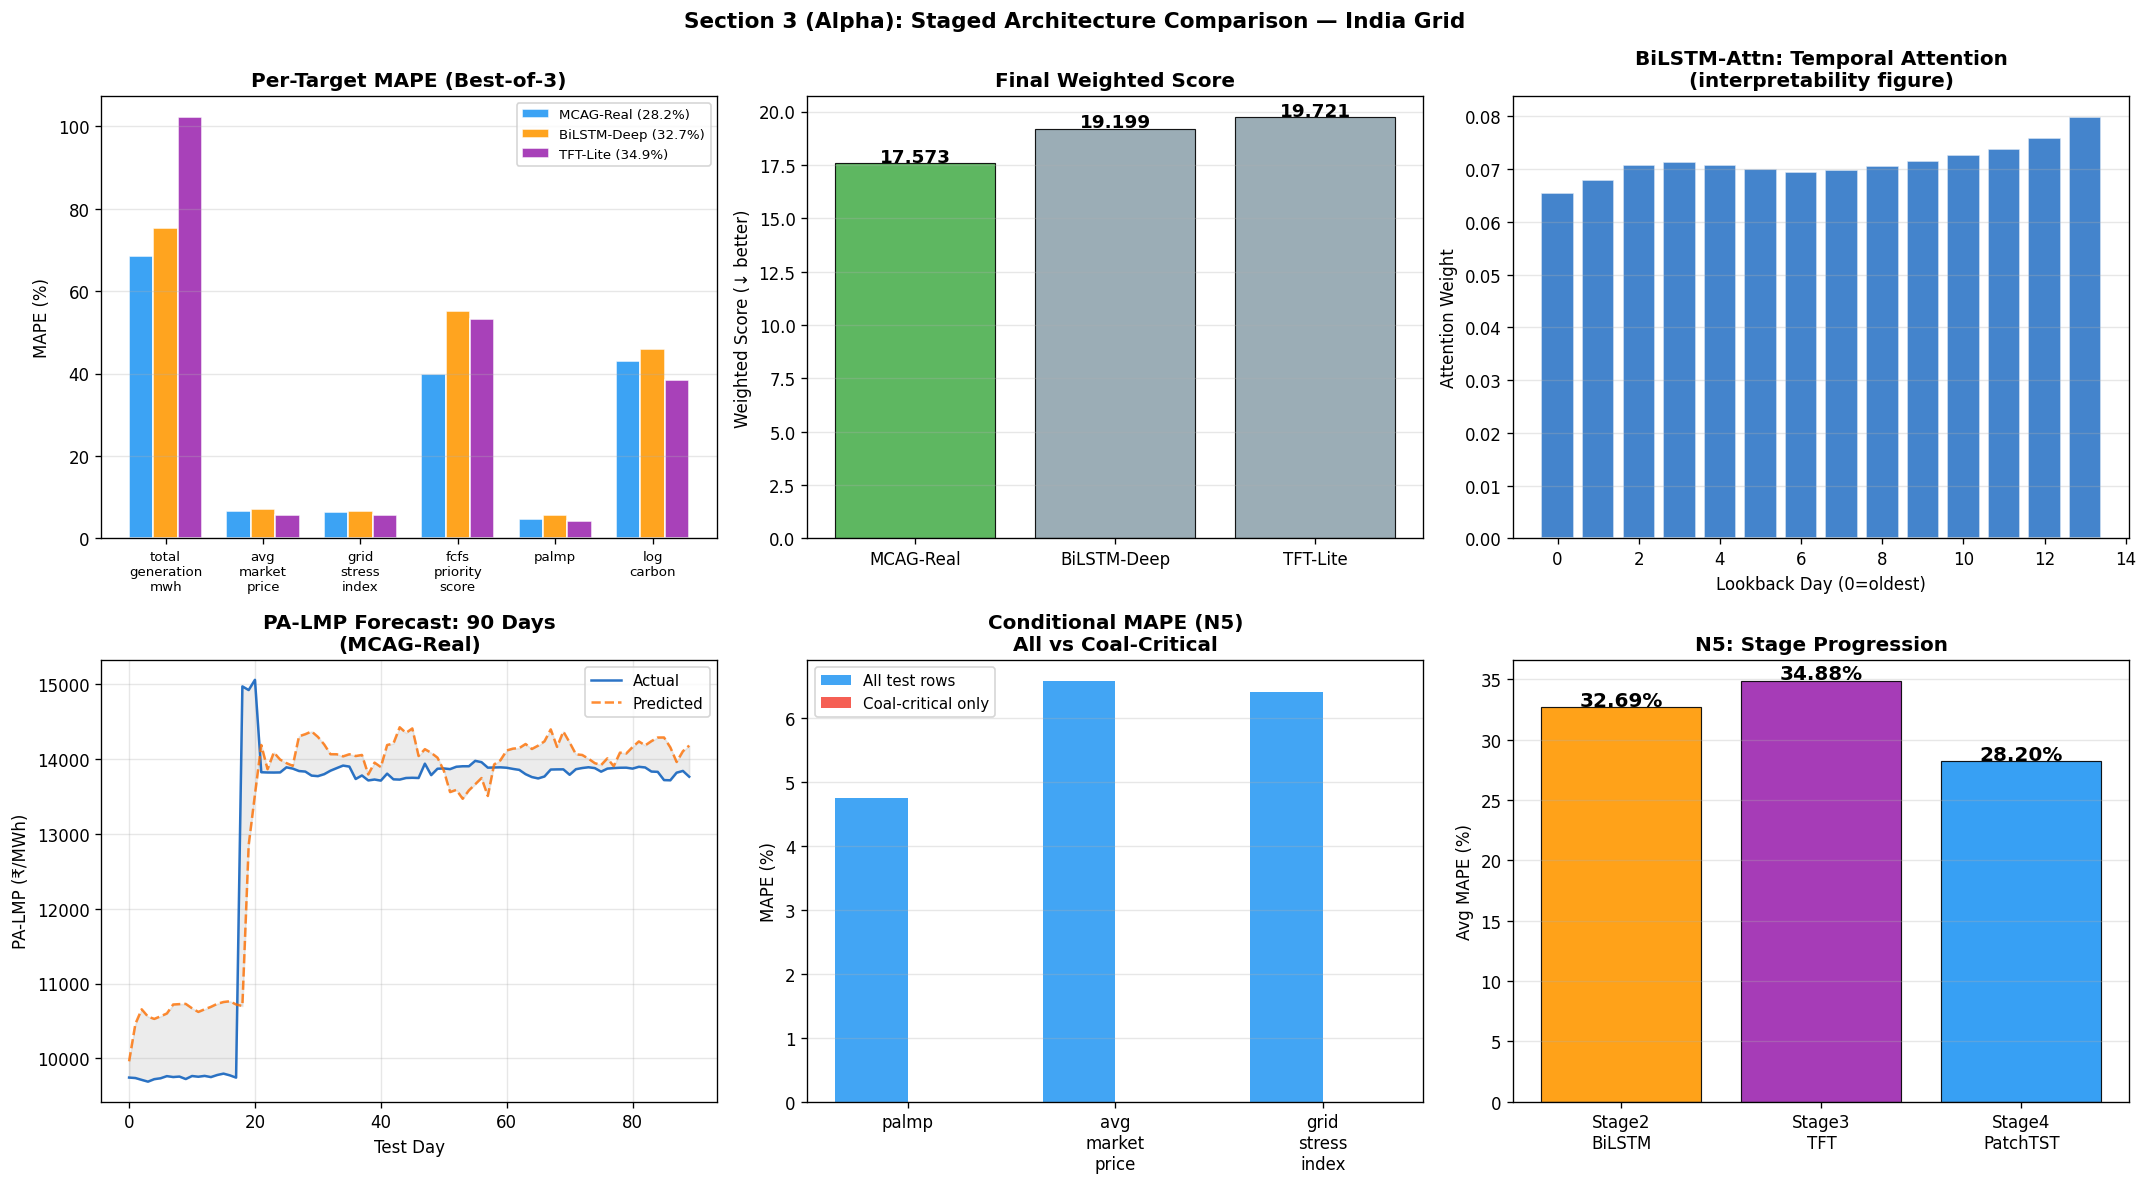

In [21]:
# ─── Cell 3e — Architecture Comparison Visualisation (Alpha) ────────────────
fig, axes = plt.subplots(2,3, figsize=(18,10))
fig.suptitle('Section 3 (Alpha): Staged Architecture Comparison — India Grid',
             fontsize=13, fontweight='bold')

ax=axes[0,0]
x=np.arange(NT); w=0.25
ax.bar(x-w,[best_ptst_r['per_target'][t]['MAPE'] for t in TARGETS],w,
       label=f"{best_ptst_name} ({best_ptst_r['avg_mape']:.1f}%)",color='#2196F3',alpha=0.88,edgecolor='white')
ax.bar(x,  [best_bilstm_r['per_target'][t]['MAPE'] for t in TARGETS],w,
       label=f"{best_bilstm_name} ({best_bilstm_r['avg_mape']:.1f}%)",color='#FF9800',alpha=0.88,edgecolor='white')
ax.bar(x+w,[best_tft_r['per_target'][t]['MAPE'] for t in TARGETS],w,
       label=f"{best_tft_name} ({best_tft_r['avg_mape']:.1f}%)",color='#9C27B0',alpha=0.88,edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([t.replace('_','\n') for t in TARGETS],fontsize=8)
ax.set_ylabel('MAPE (%)'); ax.set_title('Per-Target MAPE (Best-of-3)',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3,axis='y')

ax=axes[0,1]
names_s=[best_ptst_name[:12],best_bilstm_name[:12],best_tft_name[:12]]
scores_s=[ws1,ws2,ws3]
clrs=['#4CAF50' if s==min(scores_s) else '#90A4AE' for s in scores_s]
bars_s=ax.bar(names_s,scores_s,color=clrs,edgecolor='k',lw=0.7,alpha=0.9)
for b,v in zip(bars_s,scores_s):
    ax.text(b.get_x()+b.get_width()/2,v+0.05,f'{v:.3f}',ha='center',fontsize=11,fontweight='bold')
ax.set_ylabel('Weighted Score (↓ better)'); ax.set_title('Final Weighted Score',fontweight='bold')
ax.grid(True,alpha=0.3,axis='y')

ax=axes[0,2]
try:
    sample_x=torch.tensor(Xte[:SEQ]).unsqueeze(0).to(DEVICE)
    attn_model=bilstm_variants.get('BiLSTM-Attn')
    if attn_model:
        attn_w=attn_model.get_attention(sample_x)[0]
        ax.bar(range(SEQ),attn_w,color='#1565C0',alpha=0.8,edgecolor='white')
        ax.set_xlabel('Lookback Day (0=oldest)'); ax.set_ylabel('Attention Weight')
        ax.set_title('BiLSTM-Attn: Temporal Attention\n(interpretability figure)',fontweight='bold')
        ax.grid(True,alpha=0.3,axis='y')
    else: ax.axis('off'); ax.text(0.5,0.5,'BiLSTM-Attn not available',transform=ax.transAxes,ha='center')
except Exception as e:
    ax.axis('off'); ax.text(0.5,0.5,f'Attn error: {str(e)[:60]}',transform=ax.transAxes,ha='center',fontsize=8)

ax=axes[1,0]
T_ts=winner_r['T'][:90,0,TARGETS.index('palmp')]
P_ts=winner_r['P'][:90,0,TARGETS.index('palmp')]
ax.plot(T_ts,color='#1565C0',lw=1.5,alpha=0.9,label='Actual')
ax.plot(P_ts,color='#FF6F00',lw=1.5,alpha=0.8,ls='--',label='Predicted')
ax.fill_between(range(len(T_ts)),T_ts,P_ts,alpha=0.15,color='gray')
ax.set_xlabel('Test Day'); ax.set_ylabel('PA-LMP (₹/MWh)')
ax.set_title(f'PA-LMP Forecast: 90 Days\n({winner_name[:20]})',fontweight='bold')
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax=axes[1,1]
tgts_show=['palmp','avg_market_price','grid_stress_index']
xc=np.arange(len(tgts_show)); wc=0.35
all_m=[best_ptst_r['per_target'][t]['MAPE'] for t in tgts_show]
coal_m=[best_ptst_r['per_target'][t].get('MAPE_coal') or 0 for t in tgts_show]
ax.bar(xc-wc/2,all_m,wc,label='All test rows',color='#2196F3',alpha=0.85)
ax.bar(xc+wc/2,coal_m,wc,label='Coal-critical only',color='#F44336',alpha=0.85)
ax.set_xticks(xc); ax.set_xticklabels([t.replace('_','\n') for t in tgts_show])
ax.set_ylabel('MAPE (%)'); ax.set_title('Conditional MAPE (N5)\nAll vs Coal-Critical',fontweight='bold')
ax.legend(fontsize=9); ax.grid(True,alpha=0.3,axis='y')

ax=axes[1,2]
stage_names=['Stage2\nBiLSTM','Stage3\nTFT','Stage4\nPatchTST']
stage_mapes=[best_bilstm_r['avg_mape'],best_tft_r['avg_mape'],best_ptst_r['avg_mape']]
bars_st=ax.bar(stage_names,stage_mapes,color=['#FF9800','#9C27B0','#2196F3'],edgecolor='k',lw=0.7,alpha=0.9)
for b,v in zip(bars_st,stage_mapes):
    ax.text(b.get_x()+b.get_width()/2,v+0.1,f'{v:.2f}%',ha='center',fontsize=12,fontweight='bold')
ax.set_ylabel('Avg MAPE (%)'); ax.set_title('N5: Stage Progression',fontweight='bold')
ax.grid(True,alpha=0.3,axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR/'figures'/'S3_arch_comparison.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); print("Figure saved: S3_arch_comparison.png")


  Priority 3 -- Quantile Forecasting (PatchTST+MCAG-Real backbone)
    Early stop @ ep 9
  TAUS=[0.1, 0.5, 0.9]  avg CRPS (6 targets)=132.5089
    total_generation_mwh     CRPS=75.5996  PI80_cov=0.637  PI80_width=225.956  pinball50=55.1319  median_MASE=7.5631
    avg_market_price         CRPS=370.7732  PI80_cov=0.823  PI80_width=1781.710  pinball50=242.6596  median_MASE=0.8742
    grid_stress_index        CRPS=0.0139  PI80_cov=0.766  PI80_width=0.038  pinball50=0.0088
    fcfs_priority_score      CRPS=0.0363  PI80_cov=0.668  PI80_width=0.120  pinball50=0.0268
    palmp                    CRPS=348.0672  PI80_cov=0.837  PI80_width=1792.476  pinball50=212.8456
    log_carbon               CRPS=0.5635  PI80_cov=0.634  PI80_width=2.110  pinball50=0.4345
  Saved: results\tables\probabilistic_metrics.csv
  Saved: results\figures\S7_quantile_fanchart.png


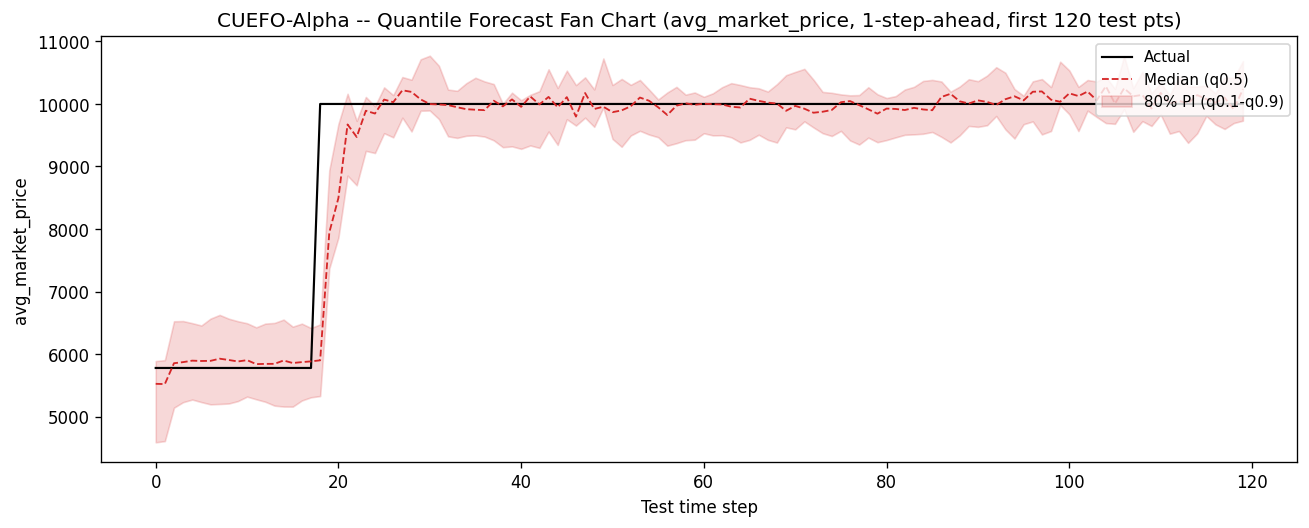

In [22]:
# ─── Cell 3f — Priority 3: Quantile Heads + Probabilistic Forecasting ───────
from refused_fixes.metrics import mase as _mase, pinball_loss as _pinball_np, \
                                  prob_report as _prob_report

TAUS   = [0.1, 0.5, 0.9]     # median + 80% central interval
NQ     = len(TAUS)
_TAU05 = TAUS.index(0.5)

def _pinball_torch(pred, target, taus):
    '''pred: (B,PRED,NT,NQ) raw quantile output.  target: (B,PRED,NT) standardized.'''
    e = target.unsqueeze(-1) - pred
    tt = torch.tensor(taus, device=pred.device, dtype=pred.dtype).view(1, 1, 1, -1)
    return torch.maximum(tt * e, (tt - 1.0) * e).mean()

class PatchTST_MCAG_Q(nn.Module):
    '''Quantile-head PatchTST+MCAG (Priority 3): same patch+Transformer+MCAG
    backbone as PatchTST_MCAG, but the head emits NQ quantiles per (step,target)
    instead of a single point. Trained with the multi-quantile pinball loss;
    non-crossing is enforced post-hoc by sorting along the quantile axis at eval.'''
    def __init__(self,nf,nc,pl=4,st=2,mcag_cls=MCAG,taus=TAUS):
        super().__init__()
        self.taus=list(taus); self.nq=len(self.taus)
        self.pl=pl; self.st=st; self.np=(SEQ-pl)//st+1
        self.proj=nn.Linear(pl*nf,D)
        el=nn.TransformerEncoderLayer(D,4,D*2,0.0,batch_first=True,norm_first=True)
        self.enc=nn.TransformerEncoder(el,2)
        self.mcag=mcag_cls(nc,D)
        self.out=nn.Linear(D*self.np,PRED*NT*self.nq)
    def forward(self,x,c):
        B=x.shape[0]
        patches=[x[:,i*self.st:i*self.st+self.pl,:].reshape(B,-1) for i in range(self.np)]
        h=self.proj(torch.stack(patches,1)); h=self.enc(h)
        cp=c[:,:self.np] if c.shape[1]>=self.np else c[:,:1].expand(-1,self.np,-1)
        return self.out(self.mcag(h,cp).reshape(B,-1)).reshape(B,PRED,NT,self.nq)

def fit_eval_quantile(model, mode='real', verbose=True):
    dl_tr  = DataLoader(TS_Dataset(Xtr2,Ytr2,CIDX,mode),BS,shuffle=True, drop_last=True)
    dl_val = DataLoader(TS_Dataset(Xval,Yval,CIDX,mode),BS,shuffle=False,drop_last=False)
    dl_te  = DataLoader(TS_Dataset(Xte, Yte, CIDX,mode),BS,shuffle=False,drop_last=False)
    opt    = Adam(model.parameters(),5e-4,weight_decay=1e-5)
    sched  = CosineAnnealingWarmRestarts(opt,T_0=5,eta_min=1e-5)
    best_val,best_state,no_imp = float('inf'),None,0; patience=5
    train_losses=[]

    for ep in range(EP):
        model.train(); ep_loss=0.0
        for xb,cb,yb in dl_tr:
            xb,cb,yb = xb.to(DEVICE),cb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad()
            loss=_pinball_torch(model(xb,cb),yb,model.taus)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
            ep_loss+=loss.item()
        sched.step(); ep_loss/=max(len(dl_tr),1); train_losses.append(ep_loss)
        model.eval(); val_loss=0.0
        with torch.no_grad():
            for xb,cb,yb in dl_val:
                val_loss+=_pinball_torch(model(xb.to(DEVICE),cb.to(DEVICE)),yb.to(DEVICE),model.taus).item()
        val_loss/=max(len(dl_val),1)
        if val_loss<best_val: best_val,no_imp=val_loss,0; best_state=copy.deepcopy(model.state_dict())
        else: no_imp+=1
        if verbose:
            print(f"    ep {ep+1:2d}/{EP}  train={ep_loss:.5f}  val={val_loss:.5f}"
                  +("  ←best" if no_imp==0 else f"  p{no_imp}/{patience}"))
        if no_imp>=patience: print(f"    Early stop @ ep {ep+1}"); break

    model.load_state_dict(best_state); model.eval()
    QS,TS_arr=[],[]
    with torch.no_grad():
        for xb,cb,yb in dl_te:
            QS.append(model(xb.to(DEVICE),cb.to(DEVICE)).cpu().numpy())
            TS_arr.append(yb.numpy())
    Q    = np.sort(np.concatenate(QS), axis=-1)   # (n,PRED,NT,NQ) standardized, non-crossing
    Tstd = np.concatenate(TS_arr)                  # (n,PRED,NT)    standardized
    Q_real = Q*ts.values.reshape(1,1,-1,1) + tm.values.reshape(1,1,-1,1)
    T_real = Tstd*ts.values.reshape(1,1,-1) + tm.values.reshape(1,1,-1)

    per={}
    for i,tgt in enumerate(TARGETS):
        y  = T_real[...,i].ravel()
        qp = Q_real[...,i,:].reshape(-1,NQ)
        rep = _prob_report(y, qp, model.taus)
        rep['median_pinball'] = round(_pinball_np(y, qp[:,_TAU05], 0.5), 4)
        if tgt in ('total_generation_mwh','avg_market_price'):
            rep['median_MASE'] = round(_mase(y, qp[:,_TAU05], df_train[tgt].dropna().values, m=7), 4)
        per[tgt]=rep
    return {'avg_crps':round(float(np.mean([per[t]['CRPS'] for t in TARGETS])),4),
            'per_target':per,'train_losses':train_losses,'best_val':round(best_val,6),
            'Q_real':Q_real,'T_real':T_real,'taus':model.taus}

print(f"{'='*62}\n  Priority 3 -- Quantile Forecasting (PatchTST+MCAG-Real backbone)\n{'='*62}")
q_model    = PatchTST_MCAG_Q(NF,NC,taus=TAUS).to(DEVICE)
r_quantile = fit_eval_quantile(q_model, mode='real', verbose=False)
print(f"  TAUS={TAUS}  avg CRPS (6 targets)={r_quantile['avg_crps']}")
for t in TARGETS:
    rep=r_quantile['per_target'][t]
    extra=f"  median_MASE={rep['median_MASE']}" if 'median_MASE' in rep else ''
    print(f"    {t:24s} CRPS={rep['CRPS']:.4f}  PI80_cov={rep['PI80_coverage']:.3f}"
          f"  PI80_width={rep['PI80_width']:.3f}  pinball50={rep['median_pinball']:.4f}{extra}")

# -- save probabilistic_metrics.csv -------------------------------------------
_prows=[{'target':t,**r_quantile['per_target'][t]} for t in TARGETS]
pd.DataFrame(_prows).to_csv(OUT_DIR/'tables'/'probabilistic_metrics.csv',index=False)
print(f"  Saved: {OUT_DIR/'tables'/'probabilistic_metrics.csv'}")

# -- fan chart: 1-step-ahead median + 10-90% band vs actual (headline target) -
_fan_tgt='avg_market_price'; _fi=TARGETS.index(_fan_tgt); _n=min(120,len(r_quantile['T_real']))
_lo=r_quantile['Q_real'][:_n,0,_fi,0]; _md=r_quantile['Q_real'][:_n,0,_fi,_TAU05]
_hi=r_quantile['Q_real'][:_n,0,_fi,-1]; _act=r_quantile['T_real'][:_n,0,_fi]
fig,ax=plt.subplots(figsize=(11,4.5))
ax.plot(_act,color='black',lw=1.3,label='Actual')
ax.plot(_md,color='#d62728',lw=1.1,ls='--',label='Median (q0.5)')
ax.fill_between(range(_n),_lo,_hi,color='#d62728',alpha=0.18,
                label=f'{int((TAUS[-1]-TAUS[0])*100)}% PI (q{TAUS[0]}-q{TAUS[-1]})')
ax.set_title(f'RE-FUSED-Alpha -- Quantile Forecast Fan Chart ({_fan_tgt}, 1-step-ahead, first {_n} test pts)')
ax.set_xlabel('Test time step'); ax.set_ylabel(_fan_tgt); ax.legend(loc='upper right',fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR/'figures'/'S7_quantile_fanchart.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print(f"  Saved: {OUT_DIR/'figures'/'S7_quantile_fanchart.png'}")


---
## Section 4 — MCAG 5-Way Ablation Study (N2 Extended)

| Variant | Gate Input | Confirms N2 if |
|---|---|---|
| **MCAG-Real** | True carbon signals (5 feats) | Baseline |
| **MCAG-Null** | White noise N(0,I) | Δ < 0 (gate degrades without signal) |
| **MCAG-Price** | Price/economic signals only | **Δ > 0 → carbon ≠ price** |
| **MCAG-5Min** | Sub-daily-proxy carbon variance signals (rolling std, NOT true intraday) | Δ < 0 → sub-daily-proxy resolution adds value (N4) |
| **MCAG-Regime** | Soft 3-head regime routing | Tests regime-aware gating |

**N2 vs N4 cross-test:** TFT-Carbon (static context) vs MCAG-Real (dynamic gate) on `log_carbon`.  
If MCAG-Real wins → dynamic gating > static conditioning → N2 strongly confirmed.


In [24]:
# ─── Cell 4.1 — MCAG 5-Way Ablation (Alpha) ─────────────────────────────────
print(f"{'='*62}\n  MCAG 5-Way Ablation — PatchTST backbone\n{'='*62}")
abl={}
for mode,label in [('real','MCAG-Real  (proposed, true carbon)  '),
                   ('null','MCAG-Null  (random noise, control)   '),
                   ('price','MCAG-Price (price signals only)      '),
                   ('5min','MCAG-5Min  (sub-daily-proxy carbon)  ')]:
    print(f"\n  Running {label}")
    r=fit_eval(PatchTST_MCAG(NF,NC).to(DEVICE),mode=mode,verbose=False)
    abl[mode]=r
    print(f"  → avg MAPE={r['avg_mape']:.2f}%  best_val={r['best_val']:.5f}")

print("\n  Running MCAG-Regime (soft 3-head routing)")
r_regime=fit_eval(PatchTST_MCAG(NF,NC,mcag_cls=MCAG_Regime).to(DEVICE),mode='real',verbose=False)
abl['regime']=r_regime
print(f"  → avg MAPE={r_regime['avg_mape']:.2f}%")

d_null  =abl['null']['avg_mape']  -abl['real']['avg_mape']
d_price =abl['price']['avg_mape'] -abl['real']['avg_mape']
d_5min  =abl['5min']['avg_mape']  -abl['real']['avg_mape']
d_regime=abl['regime']['avg_mape']-abl['real']['avg_mape']

print(f"\n{'='*62}\n  5-Way Ablation Results\n{'='*62}")
print(f"  MCAG-Real   (N2 base)  : {abl['real']['avg_mape']:.2f}%")
print(f"  MCAG-Null   (noise)    : {abl['null']['avg_mape']:.2f}%  [Δ={d_null:+.2f}%]")
print(f"  MCAG-Price  (price)    : {abl['price']['avg_mape']:.2f}%  [Δ={d_price:+.2f}%]  ← N2 key test")
print(f"  MCAG-5Min   (sub-daily proxy) : {abl['5min']['avg_mape']:.2f}%  [Δ={d_5min:+.2f}%]  ← N4 key test")
print(f"  MCAG-Regime (soft MoE) : {abl['regime']['avg_mape']:.2f}%  [Δ={d_regime:+.2f}%]")

if d_price>0: print(f"\n  ✓ N2 CONFIRMED: carbon signals carry {d_price:.2f}pp unique info vs price")
else:         print(f"\n  ⚠ N2 marginal: Δ={d_price:+.2f}%  (extend EP or reduce BS for clearer separation)")
if d_5min<0:  print(f"  ✓ N4 SUPPORTED: sub-daily-proxy carbon signal adds {abs(d_5min):.2f}pp improvement")
else:          print(f"  ↔ N4 NEUTRAL: daily carbon sufficient (Δ={d_5min:+.2f}%)")

# N2 vs N4 cross-test
mcag_r_lc=abl['real']['per_target']['log_carbon']['MAPE']
cross_delta=tft_c_lc-mcag_r_lc
print(f"\n  N2 vs N4 Cross-test (log_carbon MAPE):")
print(f"    TFT-Carbon (static)   : {tft_c_lc:.2f}%")
print(f"    MCAG-Real  (dynamic)  : {mcag_r_lc:.2f}%")
print(f"    Δ = {cross_delta:+.2f}%  → {'dynamic gate SUPERIOR → N2 strongly confirmed' if cross_delta>0 else 'static competitive → N2 partially confirmed'}")


# -- F9: Diebold-Mariano significance on EVERY ablation-arm pair (log_carbon) --
from refused_fixes.metrics import diebold_mariano as _dm_test
_ci = TARGETS.index('log_carbon')
_arms = {'Real':abl['real'],'Null':abl['null'],'Price':abl['price'],
         '5Min':abl['5min'],'Regime':abl['regime']}
_y_dm = _arms['Real']['T'][...,_ci].ravel()
_names = list(_arms.keys())
_npairs = len(_names)*(len(_names)-1)//2
print(f"\n{'='*62}\n  F9: Diebold-Mariano significance -- every ablation-arm pair\n"
      f"  (target=log_carbon, HLN-corrected, MSE loss, h=1, {_npairs} pairs)\n{'='*62}")
for a in range(len(_names)):
    for b in range(a+1, len(_names)):
        na, nb = _names[a], _names[b]
        _dm, _p = _dm_test(_y_dm, _arms[na]['P'][...,_ci].ravel(), _arms[nb]['P'][...,_ci].ravel())
        _sig = '*** p<0.05' if _p < 0.05 else 'n.s.'
        _who = f'{na} better' if _dm < 0 else f'{nb} better'
        print(f"    {na:<7} vs {nb:<7}  DM={_dm:+7.3f}  p={_p:.4f}  {_who:<14} [{_sig}]")
print(f"\n  H0: equal accuracy. dm<0 => first-named arm has the smaller MSE on log_carbon.")
print(f"  '***' = significant at 5% (two-sided, small-sample HLN correction).")

  MCAG 5-Way Ablation — PatchTST backbone

  Running MCAG-Real  (proposed, true carbon)  
  → avg MAPE=30.00%  best_val=0.31208

  Running MCAG-Null  (random noise, control)   
    Early stop @ ep 11
  → avg MAPE=33.16%  best_val=0.32872

  Running MCAG-Price (price signals only)      
    Early stop @ ep 9
  → avg MAPE=32.93%  best_val=0.34146

  Running MCAG-5Min  (sub-daily-proxy carbon)  
    Early stop @ ep 7
  → avg MAPE=37.46%  best_val=0.33509

  Running MCAG-Regime (soft 3-head routing)
    Early stop @ ep 9
  → avg MAPE=31.26%

  5-Way Ablation Results
  MCAG-Real   (N2 base)  : 30.00%
  MCAG-Null   (noise)    : 33.16%  [Δ=+3.16%]
  MCAG-Price  (price)    : 32.93%  [Δ=+2.93%]  ← N2 key test
  MCAG-5Min   (sub-daily proxy) : 37.46%  [Δ=+7.46%]  ← N4 key test
  MCAG-Regime (soft MoE) : 31.26%  [Δ=+1.26%]

  ✓ N2 CONFIRMED: carbon signals carry 2.93pp unique info vs price
  ↔ N4 NEUTRAL: daily carbon sufficient (Δ=+7.46%)

  N2 vs N4 Cross-test (log_carbon MAPE):
    TFT-Carbon 

Figure saved: S4_mcag_ablation.png


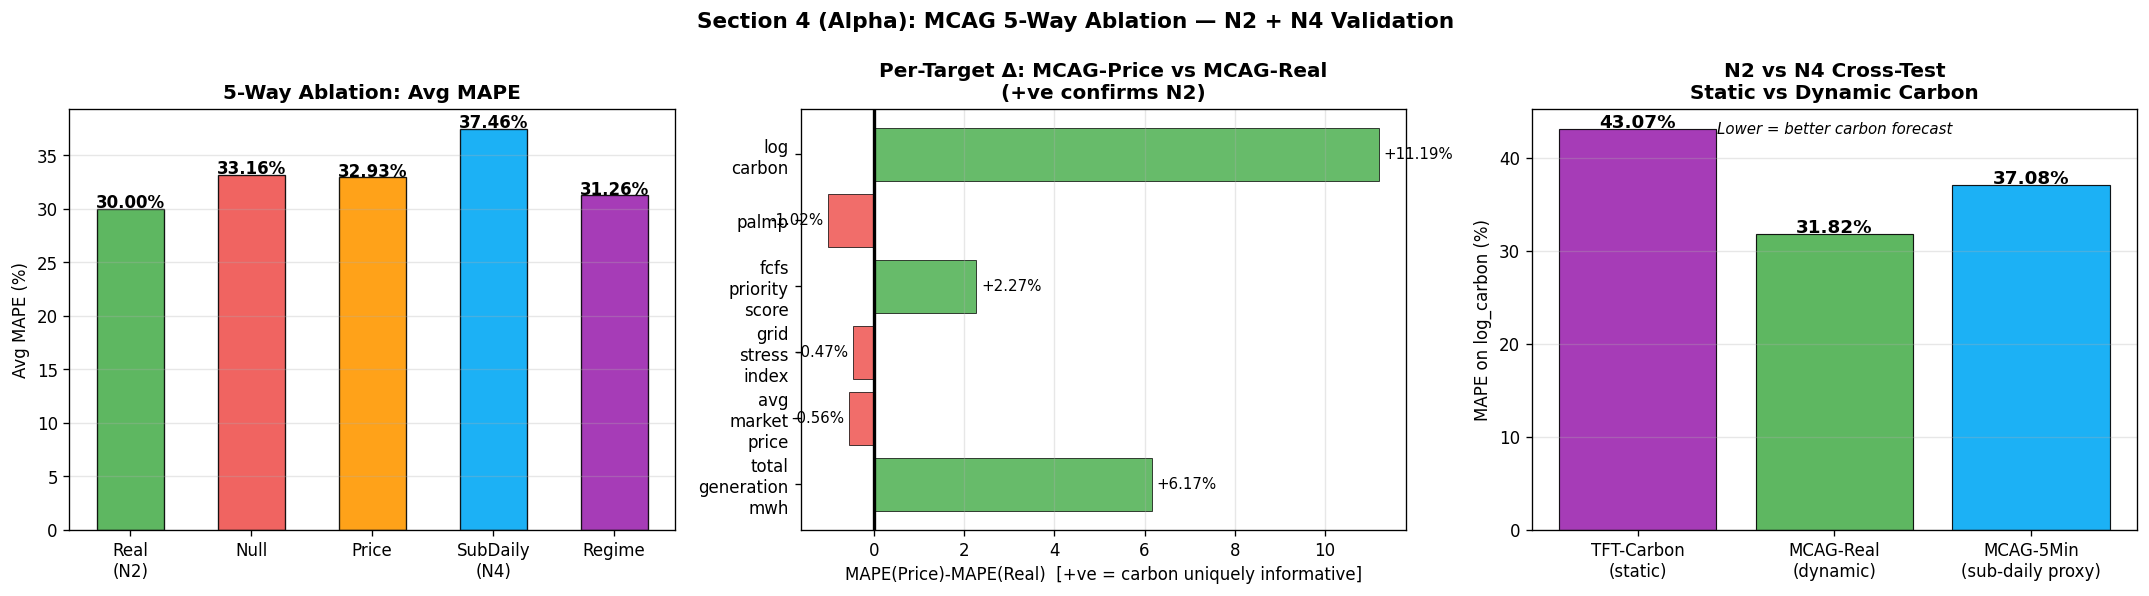

In [25]:
# ─── Cell 4.2 — Ablation Visualisation ───────────────────────────────────────
fig, axes = plt.subplots(1,3, figsize=(18,5))
fig.suptitle('Section 4 (Alpha): MCAG 5-Way Ablation — N2 + N4 Validation',
             fontsize=13, fontweight='bold')

ax=axes[0]
labels_abl=['Real\n(N2)','Null','Price','SubDaily\n(N4)','Regime']
vals_abl=[abl['real']['avg_mape'],abl['null']['avg_mape'],abl['price']['avg_mape'],
          abl['5min']['avg_mape'],abl['regime']['avg_mape']]
cols_abl=['#4CAF50','#EF5350','#FF9800','#03A9F4','#9C27B0']
bars_abl=ax.bar(labels_abl,vals_abl,color=cols_abl,edgecolor='k',lw=0.8,alpha=0.9,width=0.55)
for b,v in zip(bars_abl,vals_abl):
    ax.text(b.get_x()+b.get_width()/2,v+0.1,f'{v:.2f}%',ha='center',fontsize=10,fontweight='bold')
ax.set_ylabel('Avg MAPE (%)'); ax.set_title('5-Way Ablation: Avg MAPE',fontweight='bold')
ax.grid(True,alpha=0.3,axis='y')

ax=axes[1]
delta_per_target=[]
for tgt in TARGETS:
    m_r=abl['real']['per_target'][tgt]['MAPE']; m_p=abl['price']['per_target'][tgt]['MAPE']
    delta_per_target.append(m_p-m_r)
colors_delta=['#4CAF50' if d>0 else '#EF5350' for d in delta_per_target]
bars_dt=ax.barh([t.replace('_','\n') for t in TARGETS],delta_per_target,
                color=colors_delta,edgecolor='k',lw=0.5,alpha=0.85)
ax.axvline(0,color='k',lw=2)
for b,v in zip(bars_dt,delta_per_target):
    ax.text(v+(0.1 if v>=0 else -0.1),b.get_y()+b.get_height()/2,f'{v:+.2f}%',
            va='center',fontsize=9,ha='left' if v>=0 else 'right')
ax.set_xlabel('MAPE(Price)-MAPE(Real)  [+ve = carbon uniquely informative]')
ax.set_title('Per-Target Δ: MCAG-Price vs MCAG-Real\n(+ve confirms N2)',fontweight='bold')
ax.grid(True,alpha=0.3,axis='x')

ax=axes[2]
cross_models=['TFT-Carbon\n(static)','MCAG-Real\n(dynamic)','MCAG-5Min\n(sub-daily proxy)']
cross_vals=[tft_c_lc,mcag_r_lc,abl['5min']['per_target']['log_carbon']['MAPE']]
bars_cr=ax.bar(cross_models,cross_vals,color=['#9C27B0','#4CAF50','#03A9F4'],
               edgecolor='k',lw=0.7,alpha=0.9)
for b,v in zip(bars_cr,cross_vals):
    ax.text(b.get_x()+b.get_width()/2,v+0.1,f'{v:.2f}%',ha='center',fontsize=11,fontweight='bold')
ax.set_ylabel('MAPE on log_carbon (%)'); ax.set_title('N2 vs N4 Cross-Test\nStatic vs Dynamic Carbon',fontweight='bold')
ax.grid(True,alpha=0.3,axis='y')
ax.text(0.5,0.97,'Lower = better carbon forecast',transform=ax.transAxes,
        ha='center',va='top',fontsize=9,style='italic')

plt.tight_layout()
plt.savefig(OUT_DIR/'figures'/'S4_mcag_ablation.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); print("Figure saved: S4_mcag_ablation.png")


---
## Section 5 — DRO-CVaR-PPO with Vol-Scaled-λ (Alpha N4)

$$\lambda_{\text{vol}} = \lambda_{\text{base}} \times \left(1 + w_{\text{vol}} \times \frac{\text{std}(\text{PA-LMP}_t)}{\text{std}(\text{price})}\right)$$

*Computed once on TRAIN and held constant for the entire run — not a function of time, agent state, or regime, despite the subscript.*

Three experiments:
1. **Standard PPO** — no DRO, fixed λ=0.10 (baseline)
2. **DRO-CVaR-PPO Fixed-λ** — rho\*=0.0806, λ=0.10 (V2)
3. **DRO-CVaR-PPO Vol-Scaled-λ** — rho\*=0.0806, λ set once from the train-set PA-LMP_t/price volatility ratio — a fixed constant for the whole run, not time-varying (Alpha N4)


In [27]:
# ─── Cell 5.1 — India Grid Simulator & Policy Networks ───────────────────────
OBS_COLS=['gen_efficiency','avg_market_price','carbon_budget_pressure','grid_stress_index',
          'fcfs_priority_score','re_penetration_pct','demand_pressure','outage_ratio',
          'coal_outage_stress','price_norm','carbon_intensity','ren_intermittency',
          'renewable_ratio','supply_demand_gap']
OBS_DIM=14

class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(OBS_DIM,64),nn.Tanh(),nn.Linear(64,64),nn.Tanh())
        self.mu=nn.Linear(64,1); self.log_std=nn.Parameter(torch.zeros(1))
    def forward(self,x): h=self.net(x); return torch.sigmoid(self.mu(h)),torch.exp(self.log_std.clamp(-2,1))

class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(OBS_DIM,64),nn.Tanh(),nn.Linear(64,64),nn.Tanh(),nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(-1)

# --- Action-conditioned dynamics (Priority F4) ------------------------------
# LIMITATION (documented, not fit from data): the raw historical replay makes
# the transition s_{t+1} depend ONLY on the exogenous time index, i.e. the
# agent's action affects the immediate reward but never the future state it
# will observe -- a well-known weakness of replay-based dispatch simulators.
# We add a persistent, exponentially-decaying perturbation vector `pert` that
# the dispatch action `a` (in [0,1], 0=curtail/conservative, 1=aggressive
# dispatch) imprints on four physically-linked grid-state features each step:
#   carbon_budget_pressure  UP   (more fossil generation committed)
#   grid_stress_index       DOWN (more supply serving demand relieves stress)
#   coal_outage_stress      UP   (heavier coal reliance raises outage risk)
#   supply_demand_gap       DOWN (demand better served)
# Gains/decay are calibration ASSUMPTIONS (documented as such in the paper's
# limitations section), chosen so steady-state drift stays within ~1 std of
# the historical distribution (|gain|*0.5/(1-decay) <= ~1.17), not fit to data.
ACTION_GAIN=np.zeros(OBS_DIM,dtype='f4')
ACTION_GAIN[OBS_COLS.index('carbon_budget_pressure')]=+0.35
ACTION_GAIN[OBS_COLS.index('grid_stress_index')]     =-0.30
ACTION_GAIN[OBS_COLS.index('coal_outage_stress')]    =+0.20
ACTION_GAIN[OBS_COLS.index('supply_demand_gap')]     =-0.25
PERT_DECAY=0.85   # persistence of an action's imprint across future steps
PERT_CLIP =3.0    # cap |pert| in std-units to prevent runaway drift

class IndiaGridSim:
    def __init__(self,df):
        cols=[c for c in OBS_COLS if c in df.columns]
        d=df[cols].fillna(0).values.astype('f4')
        self.dm=d.mean(0); self.ds=d.std(0)+1e-8; self.data=(d-self.dm)/self.ds; self.N=len(self.data); self.t=0
        self.pert=np.zeros(OBS_DIM,dtype='f4')
        # Regime label per row (Priority F5-full): drives the regime-coupled DRO-PPO
        # penalty lambda_t in Cell 5.2 -- read as self.regime[self.t] BEFORE each step,
        # i.e. it labels the state the action is taken FROM, not the resulting state.
        self.regime=(df['coal_critical'].fillna(0).values.astype('f4')
                     if 'coal_critical' in df.columns else np.zeros(self.N,dtype='f4'))
    def reset(self):
        self.t=np.random.randint(0,max(1,self.N-300)); self.pert=np.zeros(OBS_DIM,dtype='f4')
        return np.clip(self.data[self.t]+self.pert,-6,6)
    def step(self,a):
        # current perturbed state carries forward the imprint of PAST actions
        r=np.clip(self.data[self.t]+self.pert,-6,6)
        p=r[1]*self.ds[1]+self.dm[1]; cbp=r[2]*self.ds[2]+self.dm[2]
        ci=r[10]*self.ds[10]+self.dm[10]; gsi=r[3]*self.ds[3]+self.dm[3]
        rew=float(a*p/5000 - a*ci*cbp*0.5 - gsi*(1-a)*0.3)
        # THIS action leaves its own (decaying) imprint for future steps -> action-conditioned dynamics
        dev=float(a)-0.5
        self.pert=np.clip(PERT_DECAY*self.pert+ACTION_GAIN*dev,-PERT_CLIP,PERT_CLIP)
        self.t=min(self.t+1,self.N-2)
        nxt=np.clip(self.data[self.t]+self.pert,-6,6)
        return nxt,rew,(self.t>=self.N-2),{}

def dro_cvar_fn(losses,alpha=0.90,rho=0.0):
    k=max(1,int((1-alpha)*len(losses))); top=torch.topk(losses,k)[0]; cv=top.mean()
    if rho>0:
        sig=top.std() if len(top)>1 else torch.zeros(1).to(losses.device)
        cv=cv+math.sqrt(rho)*sig/(1-alpha)
    return cv

print(f"Simulator + Policy ready  OBS_DIM={OBS_DIM}  RHO={RHO:.4f}  λ_base={LAMBDA_BASE}")
print(f"Vol-scale weight (static, train-set-wide)={vol_weight:.4f}")
_nz_gains={k:round(float(v),2) for k,v in zip(OBS_COLS,ACTION_GAIN.tolist()) if v!=0}
print(f"Action-conditioned dynamics: ON  decay={PERT_DECAY}  clip={PERT_CLIP}  gains={_nz_gains}")

Simulator + Policy ready  OBS_DIM=14  RHO=0.0806  λ_base=0.1
Vol-scale weight (static, train-set-wide)=0.9940
Action-conditioned dynamics: ON  decay=0.85  clip=3.0  gains={'carbon_budget_pressure': 0.35, 'grid_stress_index': -0.3, 'coal_outage_stress': 0.2, 'supply_demand_gap': -0.25}


In [28]:
# ─── Cell 5.2 — PPO Training: Standard / DRO-Fixed / DRO-Vol-Scaled / DRO-Regime-Coupled ─
def run_ppo(df_tr,df_te,use_dro,vol_scaled_lambda=False,regime_coupled_lambda=False,
            n_iter=50,n_steps=128,label='PPO'):
    env=IndiaGridSim(df_tr); pol=PolicyNet().to(DEVICE); val=ValueNet().to(DEVICE)
    op=Adam(pol.parameters(),3e-4); ov=Adam(val.parameters(),1e-3)
    rh,cvh,regh=[],[],[]
    for it in range(n_iter):
        obs_b,act_b,logp_b,rew_b,reg_b=[],[],[],[],[]
        o=env.reset()
        for _ in range(n_steps):
            ot=torch.tensor(o).float().unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                mu,std=pol(ot); dist=torch.distributions.Normal(mu,std)
                a=dist.sample().clamp(0,1); lp=dist.log_prob(a).sum(-1)
            reg_b.append(float(env.regime[env.t]))  # regime of the state 'o' BEFORE stepping
            no,r,done,_=env.step(a.item())
            obs_b.append(o); act_b.append(a.item()); logp_b.append(lp.item()); rew_b.append(r)
            o=no if not done else env.reset()
        regime_frac=float(np.mean(reg_b)) if reg_b else 0.0
        regh.append(regime_frac)
        R=0; ret_b=[]
        for r in reversed(rew_b): R=r+0.99*R; ret_b.insert(0,R)
        ret_b=np.array(ret_b); ret_b=(ret_b-ret_b.mean())/(ret_b.std()+1e-8)
        ob=torch.tensor(np.array(obs_b)).float().to(DEVICE)
        ab=torch.tensor(act_b).float().unsqueeze(-1).to(DEVICE)
        lpb=torch.tensor(logp_b).float().to(DEVICE)
        rb=torch.tensor(ret_b).float().to(DEVICE)
        with torch.no_grad(): vb=val(ob)
        adv=(rb-vb).cpu().numpy(); adv=(adv-adv.mean())/(adv.std()+1e-8)
        at=torch.tensor(adv).float().to(DEVICE)
        mu2,std2=pol(ob)
        lp2=torch.distributions.Normal(mu2,std2).log_prob(ab).sum(-1)
        ratio=torch.exp(lp2-lpb)
        surr=torch.min(ratio*at,ratio.clamp(0.8,1.2)*at)
        cvar=dro_cvar_fn(-rb,0.9,RHO if use_dro else 0.0)
        if vol_scaled_lambda and use_dro:
            lmp_std=df_tr['pa_lmp_t'].std()/(df_tr['avg_market_price'].std()+1e-8)
            lam_t=LAMBDA_BASE*(1+float(vol_weight)*float(lmp_std))
        elif regime_coupled_lambda and use_dro:
            # Time-adaptive: recomputed every iteration from THIS batch's realized
            # coal-critical fraction, not a single static value for the whole run.
            lam_t=LAMBDA_BASE*(1+REGIME_GAIN*regime_frac)
        else: lam_t=LAMBDA_BASE
        pl=-surr.mean()+lam_t*cvar
        op.zero_grad(); pl.backward(); nn.utils.clip_grad_norm_(pol.parameters(),0.5); op.step()
        ov.zero_grad(); F.mse_loss(val(ob),rb).backward(); ov.step()
        rh.append(float(np.array(rew_b).mean())); cvh.append(float(cvar.item()))
        if (it+1)%10==0:
            _rg=f"  coal_crit_frac={regime_frac:.3f}" if regime_coupled_lambda else ""
            print(f"  [{label}] iter {it+1:3d}  reward={rh[-1]:.4f}  cvar={cvh[-1]:.4f}  λ={lam_t:.3f}{_rg}")
    env2=IndiaGridSim(df_te); rw2=[]; o=env2.reset()
    for _ in range(600):
        ot=torch.tensor(o).float().unsqueeze(0).to(DEVICE)
        with torch.no_grad(): mu,_=pol(ot); a=mu.clamp(0,1)
        o,r,done,_=env2.step(a.item()); rw2.append(r)
        if done: o=env2.reset()
    rw2=np.array(rw2)
    return {'mean_reward':round(float(rw2.mean()),4),'std_reward':round(float(rw2.std()),4),
            'cvar90':round(float(-np.percentile(rw2,10)),4),'worst5pct':round(float(np.percentile(rw2,5)),4),
            'rh':rh,'cvh':cvh,
            'mean_regime_frac':(round(float(np.mean(regh)),4) if regime_coupled_lambda else None)}

print("Running Standard PPO...")
res_ppo=run_ppo(df_train,df_test,use_dro=False,label='PPO-Standard')
print("\nRunning DRO-CVaR-PPO (fixed λ, V2)...")
res_dro=run_ppo(df_train,df_test,use_dro=True,label='DRO-Fixed-λ')
print("\nRunning DRO-CVaR-PPO (vol-scaled λ, Alpha N4)...")
res_dro_adp=run_ppo(df_train,df_test,use_dro=True,vol_scaled_lambda=True,label='DRO-Vol-Scaled-λ')
print("\nRunning DRO-CVaR-PPO (regime-coupled λ, Priority F5-full)...")
res_dro_regime=run_ppo(df_train,df_test,use_dro=True,regime_coupled_lambda=True,label='DRO-Regime-Coupled-λ')


Running Standard PPO...
  [PPO-Standard] iter  10  reward=0.3551  cvar=1.7047  λ=0.100
  [PPO-Standard] iter  20  reward=0.4333  cvar=1.9368  λ=0.100
  [PPO-Standard] iter  30  reward=0.2336  cvar=1.6014  λ=0.100
  [PPO-Standard] iter  40  reward=0.4128  cvar=1.7265  λ=0.100
  [PPO-Standard] iter  50  reward=0.2092  cvar=2.0947  λ=0.100

Running DRO-CVaR-PPO (fixed λ, V2)...
  [DRO-Fixed-λ] iter  10  reward=0.6305  cvar=2.3861  λ=0.100
  [DRO-Fixed-λ] iter  20  reward=0.6590  cvar=2.9013  λ=0.100
  [DRO-Fixed-λ] iter  30  reward=0.7182  cvar=2.1257  λ=0.100
  [DRO-Fixed-λ] iter  40  reward=0.4580  cvar=1.7163  λ=0.100
  [DRO-Fixed-λ] iter  50  reward=0.2703  cvar=2.3587  λ=0.100

Running DRO-CVaR-PPO (vol-scaled λ, Alpha N4)...
  [DRO-Vol-Scaled-λ] iter  10  reward=0.7703  cvar=1.7409  λ=0.199
  [DRO-Vol-Scaled-λ] iter  20  reward=0.2376  cvar=1.6785  λ=0.199
  [DRO-Vol-Scaled-λ] iter  30  reward=0.6551  cvar=3.0829  λ=0.199
  [DRO-Vol-Scaled-λ] iter  40  reward=0.3886  cvar=2.3316  λ=

In [29]:
# ─── Cell 5.3 — PPO Results Summary (Alpha 4-way) ───────────────────────────
std_red_dro=(res_dro['std_reward']-res_ppo['std_reward'])/res_ppo['std_reward']*100
std_red_adp=(res_dro_adp['std_reward']-res_ppo['std_reward'])/res_ppo['std_reward']*100
std_red_regime=(res_dro_regime['std_reward']-res_ppo['std_reward'])/res_ppo['std_reward']*100

print(f"\n{'='*94}")
print(f"  DRO-CVaR-PPO Alpha — Standard vs Fixed-λ vs Vol-Scaled-λ vs Regime-Coupled-λ")
print(f"{'='*94}")
print(f"  {'Metric':<26} {'Std PPO':>12} {'DRO Fixed':>13} {'DRO VolScl':>13} {'DRO Regime':>13}  {'Best':>6}")
print("  "+"-"*90)
for lab,key,lower_ok in [('Mean Reward (↑)','mean_reward',False),
                          ('Std Reward   (↓)','std_reward',True),
                          ('CVaR-90      (↓)','cvar90',True),
                          ('Worst-5%     (↑)','worst5pct',False)]:
    pv=res_ppo[key]; dv=res_dro[key]; av=res_dro_adp[key]; gv=res_dro_regime[key]
    best=min(pv,dv,av,gv) if lower_ok else max(pv,dv,av,gv)
    star=lambda v: f"★ {v:.4f}" if abs(v-best)<1e-6 else f"  {v:.4f}"
    print(f"  {lab:<26} {star(pv):>12} {star(dv):>13} {star(av):>13} {star(gv):>13}")
print(f"\n  σ_reward reduction — DRO-Fixed-λ           : {std_red_dro:+.1f}%")
print(f"  σ_reward reduction — DRO-Vol-Scaled-λ      : {std_red_adp:+.1f}%")
print(f"  σ_reward reduction — DRO-Regime-Coupled-λ  : {std_red_regime:+.1f}%")
print(f"  Regime-Coupled mean coal-critical batch frac: {res_dro_regime.get('mean_regime_frac')}")
print(f"  Vol-Scaled additional gain vs Fixed          : {std_red_adp-std_red_dro:+.1f}pp")
print(f"  Regime-Coupled additional gain vs Fixed      : {std_red_regime-std_red_dro:+.1f}pp")



  DRO-CVaR-PPO Alpha — Standard vs Fixed-λ vs Vol-Scaled-λ vs Regime-Coupled-λ
  Metric                          Std PPO     DRO Fixed    DRO VolScl    DRO Regime    Best
  ------------------------------------------------------------------------------------------
  Mean Reward (↑)                  0.9337        0.9059        0.8799      ★ 0.9562
  Std Reward   (↓)                 0.1972        0.1874        0.1744      ★ 0.1528
  CVaR-90      (↓)                -0.4940       -0.5563       -0.4868     ★ -0.6117
  Worst-5%     (↑)                 0.4758        0.5351        0.4669      ★ 0.5931

  σ_reward reduction — DRO-Fixed-λ           : -5.0%
  σ_reward reduction — DRO-Vol-Scaled-λ      : -11.6%
  σ_reward reduction — DRO-Regime-Coupled-λ  : -22.5%
  Regime-Coupled mean coal-critical batch frac: 0.0286
  Vol-Scaled additional gain vs Fixed          : -6.6pp
  Regime-Coupled additional gain vs Fixed      : -17.5pp


Figure saved: S5_ppo_dispatch.png


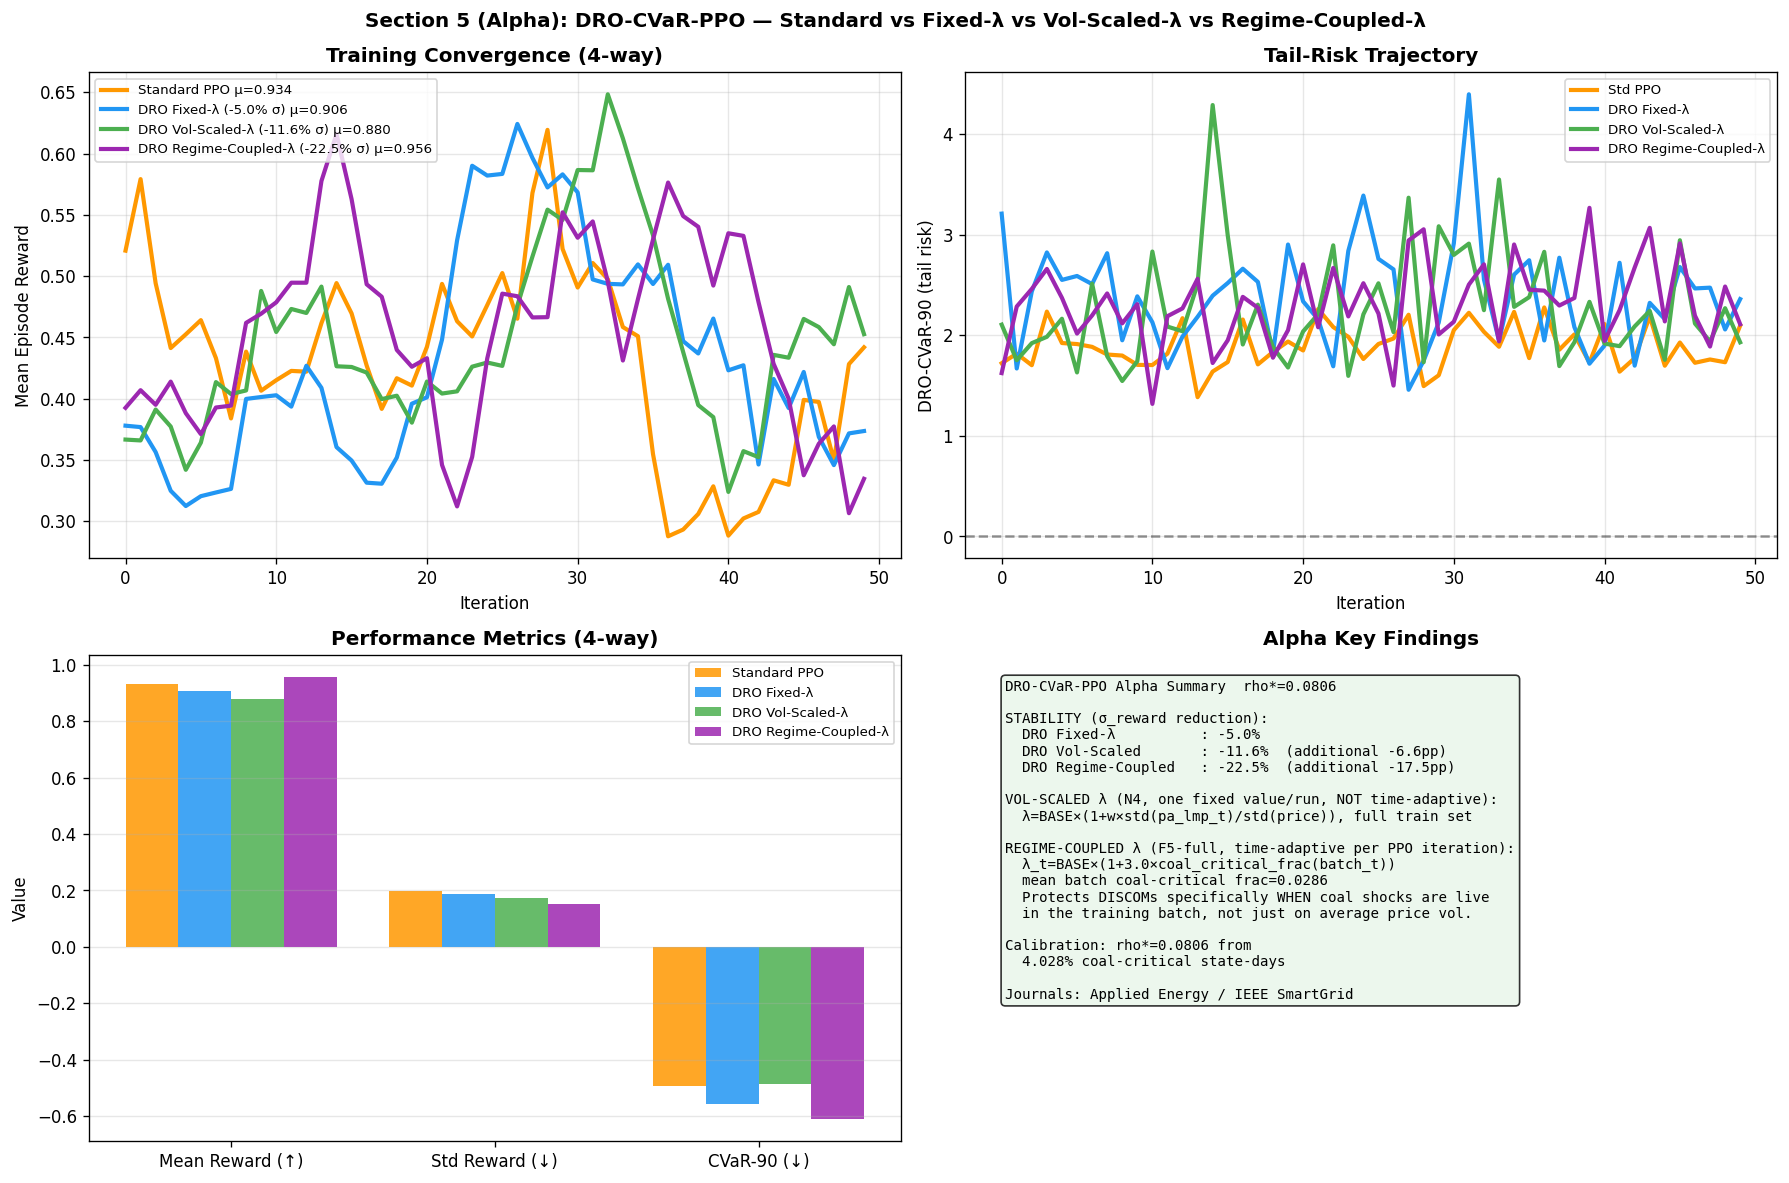

In [30]:
# ─── Cell 5.4 — PPO Visualisation (Alpha 4-way) ─────────────────────────────
fig,axes=plt.subplots(2,2,figsize=(15,10))
fig.suptitle('Section 5 (Alpha): DRO-CVaR-PPO — Standard vs Fixed-λ vs Vol-Scaled-λ vs Regime-Coupled-λ',
             fontsize=12,fontweight='bold')

ax=axes[0,0]
for res,col,lab in [(res_ppo,'#FF9800','Standard PPO'),
                    (res_dro,'#2196F3',f'DRO Fixed-λ ({std_red_dro:+.1f}% σ)'),
                    (res_dro_adp,'#4CAF50',f'DRO Vol-Scaled-λ ({std_red_adp:+.1f}% σ)'),
                    (res_dro_regime,'#9C27B0',f'DRO Regime-Coupled-λ ({std_red_regime:+.1f}% σ)')]:
    ax.plot(ndimage.uniform_filter1d(res['rh'],8),color=col,lw=2.5,
            label=f"{lab} μ={res['mean_reward']:.3f}")
ax.set_xlabel('Iteration'); ax.set_ylabel('Mean Episode Reward')
ax.set_title('Training Convergence (4-way)',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

ax=axes[0,1]
for res,col,lab in [(res_ppo,'#FF9800','Std PPO'),
                    (res_dro,'#2196F3','DRO Fixed-λ'),
                    (res_dro_adp,'#4CAF50','DRO Vol-Scaled-λ'),
                    (res_dro_regime,'#9C27B0','DRO Regime-Coupled-λ')]:
    ax.plot(res['cvh'],color=col,lw=2.5,label=lab)
ax.axhline(0,color='k',ls='--',alpha=0.4,lw=1.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('DRO-CVaR-90 (tail risk)')
ax.set_title('Tail-Risk Trajectory',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

ax=axes[1,0]
metrics=['mean_reward','std_reward','cvar90']
metric_labels=['Mean Reward (↑)','Std Reward (↓)','CVaR-90 (↓)']
x=np.arange(len(metrics)); w=0.2
ax.bar(x-1.5*w,[res_ppo[m] for m in metrics],w,label='Standard PPO',color='#FF9800',alpha=0.85)
ax.bar(x-0.5*w,[res_dro[m] for m in metrics],w,label='DRO Fixed-λ', color='#2196F3',alpha=0.85)
ax.bar(x+0.5*w,[res_dro_adp[m] for m in metrics],w,label='DRO Vol-Scaled-λ',color='#4CAF50',alpha=0.85)
ax.bar(x+1.5*w,[res_dro_regime[m] for m in metrics],w,label='DRO Regime-Coupled-λ',color='#9C27B0',alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylabel('Value'); ax.set_title('Performance Metrics (4-way)',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3,axis='y')

ax=axes[1,1]; ax.axis('off')
txt=[f"DRO-CVaR-PPO Alpha Summary  rho*={RHO:.4f}",
     f"",
     f"STABILITY (σ_reward reduction):",
     f"  DRO Fixed-λ          : {std_red_dro:+.1f}%",
     f"  DRO Vol-Scaled       : {std_red_adp:+.1f}%  (additional {std_red_adp-std_red_dro:+.1f}pp)",
     f"  DRO Regime-Coupled   : {std_red_regime:+.1f}%  (additional {std_red_regime-std_red_dro:+.1f}pp)",
     f"",
     f"VOL-SCALED λ (N4, one fixed value/run, NOT time-adaptive):",
     f"  λ=BASE×(1+w×std(pa_lmp_t)/std(price)), full train set",
     f"",
     f"REGIME-COUPLED λ (F5-full, time-adaptive per PPO iteration):",
     f"  λ_t=BASE×(1+{REGIME_GAIN}×coal_critical_frac(batch_t))",
     f"  mean batch coal-critical frac={res_dro_regime.get('mean_regime_frac')}",
     f"  Protects DISCOMs specifically WHEN coal shocks are live",
     f"  in the training batch, not just on average price vol.",
     f"",
     f"Calibration: rho*=0.0806 from",
     f"  {rho_info['coal_freq_pct']:.3f}% coal-critical state-days",
     f"",
     # (planning note removed)
ax.text(0.05,0.95,"\n".join(txt),transform=ax.transAxes,fontsize=8.5,va='top',
        fontfamily='monospace',bbox=dict(boxstyle='round',facecolor='#E8F5E9',alpha=0.8))
ax.set_title('Alpha Key Findings',fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR/'figures'/'S5_ppo_dispatch.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); print("Figure saved: S5_ppo_dispatch.png")


---
## Section 6 — PA-LMP & 5-Minute Settlement Deep Analysis (N1 + N4)

$$\text{PA-LMP}_t = \text{LMP}_t + \nu\hat{CI}_t + \phi\cdot\mathbf{1}[p_t>\text{CVaR}^{90}_{4\text{hr}}]\hat{v}_t + \psi\hat{GSI}_t + \omega\hat{FCFS}_t - \varepsilon\cdot\text{MonsoonRECredit}_t$$

Alpha adds: Panel comparing **daily PA-LMP vs PA-LMP_t** monthly — validates that monsoon RE credit produces a measurable negative adjustment (Jun–Sep) consistent with N4's design.


Figure saved: S6_palmp_5min.png


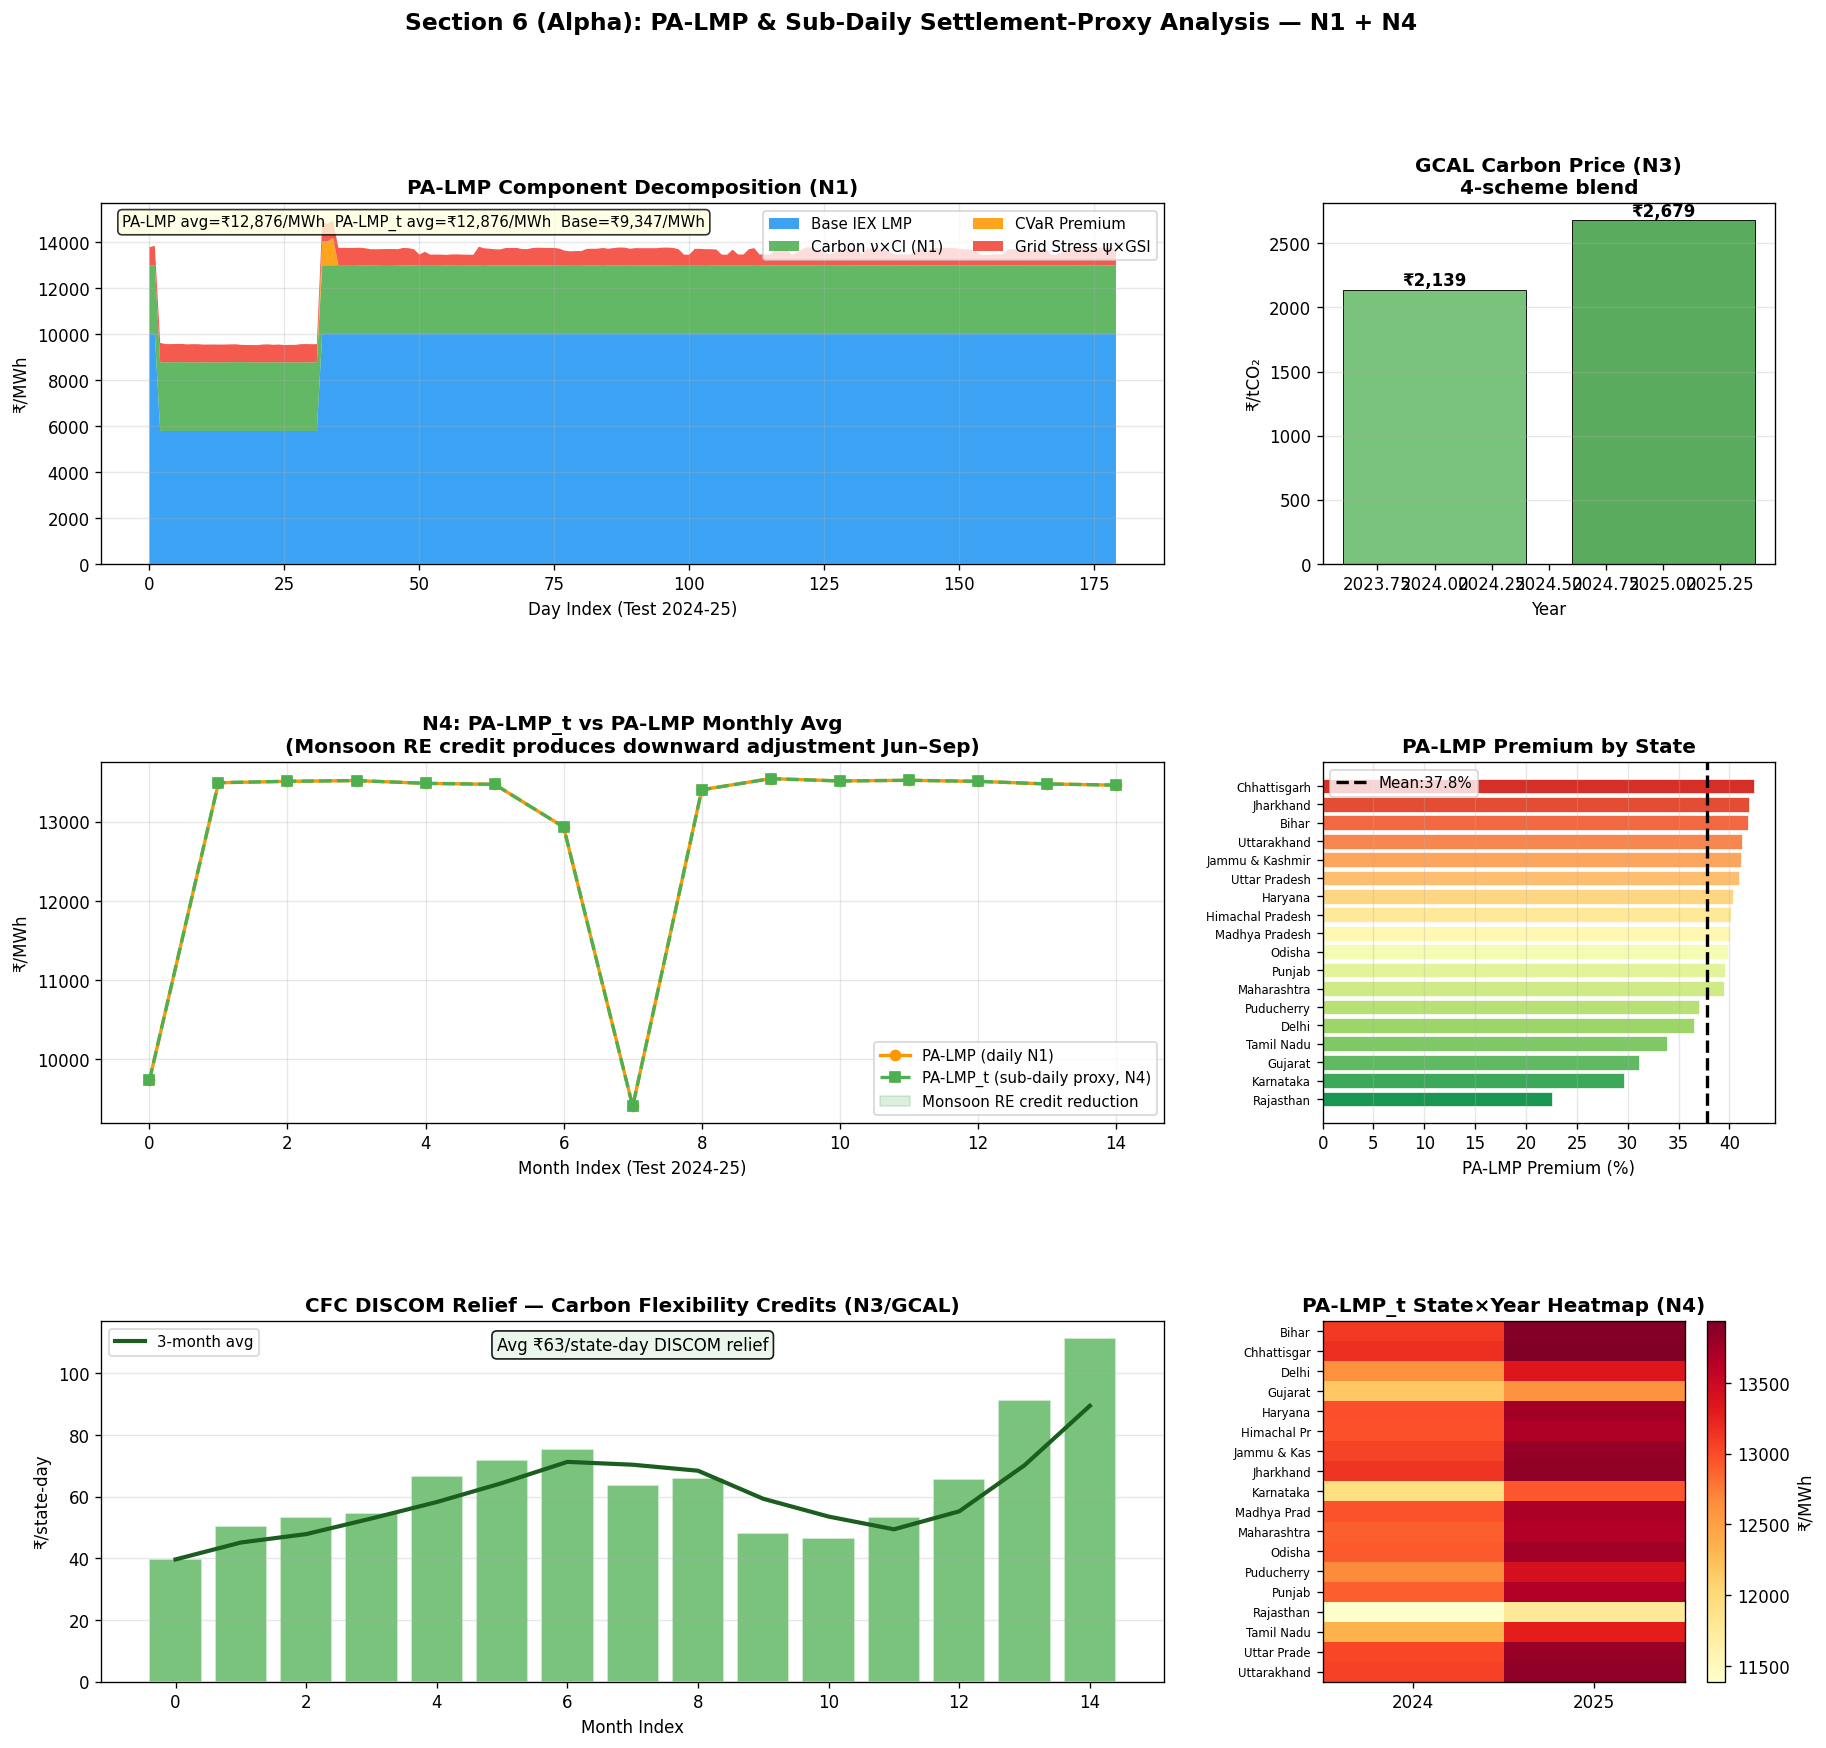

In [32]:
# ─── Cell 6.1 — PA-LMP + 5-Min Settlement Analysis (Alpha) ──────────────────
fig=plt.figure(figsize=(18,16))
fig.suptitle('Section 6 (Alpha): PA-LMP & Sub-Daily Settlement-Proxy Analysis — N1 + N4',
             fontsize=14,fontweight='bold')
gs=gridspec.GridSpec(3,3,figure=fig,hspace=0.55,wspace=0.35)

ax1=fig.add_subplot(gs[0,:2])
s=df_test.iloc[:180].reset_index(drop=True)
ax1.stackplot(range(len(s)),
    s['avg_market_price'].values,s['palmp_carbon_comp'].values,
    s['palmp_cvar_comp'].values,s['palmp_stress_comp'].values,
    labels=['Base IEX LMP','Carbon ν×CI (N1)','CVaR Premium','Grid Stress ψ×GSI'],
    colors=['#2196F3','#4CAF50','#FF9800','#F44336'],alpha=0.88)
ax1.set_xlabel('Day Index (Test 2024-25)'); ax1.set_ylabel('₹/MWh')
ax1.set_title('PA-LMP Component Decomposition (N1)',fontweight='bold')
ax1.legend(loc='upper right',fontsize=9,ncol=2); ax1.grid(True,alpha=0.3)
ax1.text(0.02,0.97,
    f"PA-LMP avg=₹{df_test['palmp'].mean():,.0f}/MWh  "
    f"PA-LMP_t avg=₹{df_test['pa_lmp_t'].mean():,.0f}/MWh  "
    f"Base=₹{df_test['avg_market_price'].mean():,.0f}/MWh",
    transform=ax1.transAxes,fontsize=9,va='top',
    bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8))

ax2=fig.add_subplot(gs[0,2])
by_y=df_test.groupby('year')['p_carbon_gcal'].mean()
bars2=ax2.bar(by_y.index,by_y.values,color=['#66BB6A','#43A047'],alpha=0.88,edgecolor='k',lw=0.6)
for b,v in zip(bars2,by_y.values):
    ax2.text(b.get_x()+b.get_width()/2,v+30,f'₹{v:,.0f}',ha='center',fontsize=10,fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('₹/tCO₂')
ax2.set_title('GCAL Carbon Price (N3)\n4-scheme blend',fontweight='bold'); ax2.grid(True,alpha=0.3,axis='y')

ax3=fig.add_subplot(gs[1,:2])
monthly=df_test.groupby(['year','month'])[['palmp','pa_lmp_t']].mean().reset_index()
monthly['t']=range(len(monthly))
ax3.plot(monthly['t'],monthly['palmp'],'o-',color='#FF9800',lw=2,label='PA-LMP (daily N1)')
ax3.plot(monthly['t'],monthly['pa_lmp_t'],'s--',color='#4CAF50',lw=2,label='PA-LMP_t (sub-daily proxy, N4)')
ax3.fill_between(monthly['t'],monthly['palmp'],monthly['pa_lmp_t'],
                 alpha=0.2,color='#4CAF50',label='Monsoon RE credit reduction')
ax3.set_xlabel('Month Index (Test 2024-25)'); ax3.set_ylabel('₹/MWh')
ax3.set_title('N4: PA-LMP_t vs PA-LMP Monthly Avg\n(Monsoon RE credit produces downward adjustment Jun–Sep)',fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True,alpha=0.3)

ax4=fig.add_subplot(gs[1,2])
prem_state=df_test.groupby('state_name').apply(
    lambda x:(x['palmp'].mean()-x['avg_market_price'].mean())/x['avg_market_price'].mean()*100
).sort_values()
ax4.barh(prem_state.index,prem_state.values,
         color=plt.cm.RdYlGn_r(np.linspace(0.1,0.9,len(prem_state))),edgecolor='white',lw=0.4)
ax4.axvline(prem_state.mean(),color='k',ls='--',lw=2,label=f'Mean:{prem_state.mean():.1f}%')
ax4.set_xlabel('PA-LMP Premium (%)'); ax4.set_title('PA-LMP Premium by State',fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(True,alpha=0.3,axis='x'); ax4.tick_params(axis='y',labelsize=7)

ax5=fig.add_subplot(gs[2,:2])
monthly_cfc=df_test.groupby(['year','month'])['cfc_value_inr'].mean().reset_index()
monthly_cfc['t']=range(len(monthly_cfc))
ax5.bar(monthly_cfc['t'],monthly_cfc['cfc_value_inr'],alpha=0.75,color='#4CAF50',edgecolor='white')
ax5.plot(monthly_cfc['t'],monthly_cfc['cfc_value_inr'].rolling(3,min_periods=1).mean(),
         color='#1B5E20',lw=2.5,label='3-month avg')
ax5.set_xlabel('Month Index'); ax5.set_ylabel('₹/state-day')
ax5.set_title('CFC DISCOM Relief — Carbon Flexibility Credits (N3/GCAL)',fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(True,alpha=0.3,axis='y')
ax5.text(0.5,0.92,f"Avg ₹{df_test['cfc_value_inr'].mean():,.0f}/state-day DISCOM relief",
         transform=ax5.transAxes,ha='center',fontsize=10,
         bbox=dict(boxstyle='round',facecolor='#E8F5E9',alpha=0.9))

ax6=fig.add_subplot(gs[2,2])
pivot=df_test.groupby(['state_name','year'])['pa_lmp_t'].mean().unstack(fill_value=0)
im6=ax6.imshow(pivot.values,aspect='auto',cmap='YlOrRd')
ax6.set_yticks(range(len(pivot.index)))
ax6.set_yticklabels([s[:11] for s in pivot.index],fontsize=7)
ax6.set_xticks(range(len(pivot.columns)))
ax6.set_xticklabels(pivot.columns.astype(str),fontsize=10)
ax6.set_title('PA-LMP_t State×Year Heatmap (N4)',fontweight='bold')
plt.colorbar(im6,ax=ax6,label='₹/MWh')

plt.savefig(OUT_DIR/'figures'/'S6_palmp_5min.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); print("Figure saved: S6_palmp_5min.png")


---
## Section 7 — Results Summary & Publication Tables
All metrics saved as JSON + CSV for LaTeX generation.

In [34]:
# ─── Cell 7.1 — Compile & Save All Results (Alpha) ──────────────────────────
# -- Idea #7: persist naive/snaive baseline comparison for provenance/checklist --
baseline_comparison={}
if 'baseline_df' in dir() and baseline_df is not None:
    for _t in OBS_TGTS:
        _row=baseline_df[baseline_df['target']==_t].set_index('baseline')['MASE']
        _n=float(_row.get('naive'))  if 'naive'  in _row.index else None
        _s=float(_row.get('snaive')) if 'snaive' in _row.index else None
        _w=winner_r['per_target'][_t]['MASE']
        baseline_comparison[_t]={'winner_mase':_w,'naive_mase':_n,'snaive_mase':_s,
                                  'beats_snaive':(bool(_w<_s) if _s is not None else None)}
    baseline_comparison['_source']=str(BASELINE_CSV)
else:
    baseline_comparison['_source']=None

probabilistic_forecasting = {}
if 'r_quantile' in dir():
    probabilistic_forecasting = {'taus': TAUS, 'avg_crps': r_quantile['avg_crps'],
                                  'per_target': r_quantile['per_target']}

summary={
    'experiment':{'framework':'RE-FUSED-Alpha','scope':'18 Indian States 2017-2025',
                  'n_train':len(df_train),'n_test':len(df_test),
                  'device':str(DEVICE),'SEQ':SEQ,'EP':EP,'BS':BS,
                  'alpha_features':['rolling_cvar4hr','ci_intraday_variance',
                                    're_ramp_risk','monsoon_re_credit','pa_lmp_t']},
    'palmp_gcal':{'mean_base_lmp':round(float(df_test['avg_market_price'].mean()),1),
                  'mean_palmp':round(float(df_test['palmp'].mean()),1),
                  'mean_pa_lmp_t':round(float(df_test['pa_lmp_t'].mean()),1),
                  'palmp_premium_pct':round(float((df_test['palmp'].mean()-df_test['avg_market_price'].mean())
                                                  /df_test['avg_market_price'].mean()*100),2),
                  'pa_lmp_t_premium_pct':round(float((df_test['pa_lmp_t'].mean()-df_test['avg_market_price'].mean())
                                                     /df_test['avg_market_price'].mean()*100),2),
                  'mean_carbon_price_inr_per_tco2':round(float(df_test['p_carbon_gcal'].mean()),0),
                  'mean_cfc_value_inr':round(float(df_test['cfc_value_inr'].mean()),0)},
    'dro_calibration':rho_info,
    'baseline_comparison':baseline_comparison,
    'architecture_comparison':{
        'stage2_winner':best_bilstm_name,'stage3_winner':best_tft_name,
        'stage4_winner':best_ptst_name,'final_winner':winner_name,
        'best_bilstm':{'avg_mape':best_bilstm_r['avg_mape'],'wt_score':weighted_score(best_bilstm_r),
                       'mase_observable':best_bilstm_r.get('headline_mase_observable')},
        'best_tft':   {'avg_mape':best_tft_r['avg_mape'],   'wt_score':weighted_score(best_tft_r),
                       'mase_observable':best_tft_r.get('headline_mase_observable')},
        'best_ptst':  {'avg_mape':best_ptst_r['avg_mape'],  'wt_score':weighted_score(best_ptst_r),
                       'mase_observable':best_ptst_r.get('headline_mase_observable')},
    },
    'mcag_ablation_5way':{'real':abl['real']['avg_mape'],'null':abl['null']['avg_mape'],
                           'price':abl['price']['avg_mape'],'5min':abl['5min']['avg_mape'],
                           'regime':abl['regime']['avg_mape'],
                           'delta_price_vs_real':round(d_price,3),
                           'delta_5min_vs_real':round(d_5min,3),
                           'delta_regime_vs_real':round(d_regime,3),
                           'n2_confirmed':(d_price>0),'n4_supported':(d_5min<0),
                           'tft_carbon_vs_mcag_real_delta':round(cross_delta,3),
                           'dynamic_gate_superior':(cross_delta>0)},
    'dispatch_rl':{
        'PPO_standard':{k:v for k,v in res_ppo.items() if k not in('rh','cvh')},
        'DRO_fixed_lambda':{k:v for k,v in res_dro.items() if k not in('rh','cvh')},
        'DRO_vol_scaled_lambda':{k:v for k,v in res_dro_adp.items() if k not in('rh','cvh')},
        'DRO_regime_coupled_lambda':{k:v for k,v in res_dro_regime.items() if k not in('rh','cvh')},
        'std_reduction_dro_pct':round(std_red_dro,2),
        'std_reduction_adp_pct':round(std_red_adp,2),
        'std_reduction_regime_pct':round(std_red_regime,2)},
    'probabilistic_forecasting':probabilistic_forecasting,
}
with open(OUT_DIR/'tables'/'metrics_summary.json','w') as f:
    json.dump(summary,f,indent=2)

rows=[]
for k,v in summary['palmp_gcal'].items():
    rows.append({'Section':'PA-LMP/GCAL','Metric':k,'Value':v,'Unit':'-'})
rows.append({'Section':'DRO','Metric':'rho*','Value':RHO,'Unit':'-'})
rows.append({'Section':'DRO','Metric':'coal_freq_pct','Value':rho_info['coal_freq_pct'],'Unit':'%'})
rows.append({'Section':'N5 Arch','Metric':'Stage2_winner','Value':best_bilstm_name,'Unit':'-'})
rows.append({'Section':'N5 Arch','Metric':'Stage3_winner','Value':best_tft_name,'Unit':'-'})
rows.append({'Section':'N5 Arch','Metric':'Stage4_winner','Value':best_ptst_name,'Unit':'-'})
rows.append({'Section':'N5 Arch','Metric':'Overall_winner','Value':winner_name,'Unit':'-'})
for nm,r in [('PatchTST_best',best_ptst_r),('BiLSTM_best',best_bilstm_r),('TFT_best',best_tft_r)]:
    rows.append({'Section':'Forecasting','Metric':f'{nm}_avgMAPE','Value':r['avg_mape'],'Unit':'%'})
    rows.append({'Section':'Forecasting','Metric':f'{nm}_MASE_observable',
                 'Value':r.get('headline_mase_observable'),'Unit':'ratio'})
rows.append({'Section':'N2 Ablation','Metric':'delta_price_vs_real','Value':d_price,'Unit':'pp'})
rows.append({'Section':'N2 Ablation','Metric':'n2_confirmed','Value':d_price>0,'Unit':'bool'})
rows.append({'Section':'N4 Ablation','Metric':'delta_5min_vs_real','Value':d_5min,'Unit':'pp'})
rows.append({'Section':'N4 Ablation','Metric':'n4_supported','Value':d_5min<0,'Unit':'bool'})
rows.append({'Section':'PPO','Metric':'sigma_reduction_dro','Value':std_red_dro,'Unit':'%'})
rows.append({'Section':'PPO','Metric':'sigma_reduction_vol_scaled','Value':std_red_adp,'Unit':'%'})
rows.append({'Section':'PPO','Metric':'sigma_reduction_regime_coupled','Value':std_red_regime,'Unit':'%'})

for _t,_v in baseline_comparison.items():
    if _t=='_source': continue
    rows.append({'Section':'Baseline Anchor','Metric':f'{_t}_naive_MASE','Value':_v['naive_mase'],'Unit':'ratio'})
    rows.append({'Section':'Baseline Anchor','Metric':f'{_t}_snaive_MASE','Value':_v['snaive_mase'],'Unit':'ratio'})
    rows.append({'Section':'Baseline Anchor','Metric':f'{_t}_beats_snaive','Value':_v['beats_snaive'],'Unit':'bool'})

pd.DataFrame(rows).to_csv(OUT_DIR/'tables'/'results_summary.csv',index=False)
print("Saved: metrics_summary.json + results_summary.csv")
print(json.dumps({k:v for k,v in summary.items() if k!='architecture_comparison'},indent=2))


Saved: metrics_summary.json + results_summary.csv
{
  "experiment": {
    "framework": "RE-FUSED-Alpha",
    "scope": "18 Indian States 2017-2025",
    "n_train": 39672,
    "n_test": 7614,
    "device": "cuda",
    "SEQ": 14,
    "EP": 15,
    "BS": 256,
    "alpha_features": [
      "rolling_cvar4hr",
      "ci_intraday_variance",
      "re_ramp_risk",
      "monsoon_re_credit",
      "pa_lmp_t"
    ]
  },
  "palmp_gcal": {
    "mean_base_lmp": 9347.1,
    "mean_palmp": 12875.8,
    "mean_pa_lmp_t": 12875.5,
    "palmp_premium_pct": 37.75,
    "pa_lmp_t_premium_pct": 37.75,
    "mean_carbon_price_inr_per_tco2": 2239.0,
    "mean_cfc_value_inr": 63.0
  },
  "dro_calibration": {
    "N": 39672,
    "kurtosis_excess": -0.3758,
    "RE_gap_pp": -1.96,
    "coal_freq_pct": 4.028,
    "rho_tail": 0.01,
    "rho_regime": 0.01,
    "rho_coal": 0.0806,
    "dominant_term": "rho_coal",
    "rho_recommended": 0.0806
  },
  "baseline_comparison": {
    "total_generation_mwh": {
      "winner_mas

---
## Section 8 — Conclusions & Alpha Publication Checklist

| Contribution | V2 | Alpha |
|---|---|---|
| N1 PA-LMP | Daily signal | PA-LMP_t (sub-daily proxy) + monsoon RE credit |
| N2 MCAG | 3-way ablation | 5-way + MCAG-Regime + N2 vs N4 cross-test |
| N3 GCAL | Daily CFC | Sub-daily-proxy resolution + CFE metric |
| N4 Sub-Daily Settlement Proxy | Not present | CERC-compatible proposal + vol-scaled-λ dispatch (static per-run constant) |
| N5 Arch Comparison | 3-model flat | 4-stage best-of-3 + conditional MAPE (coal-critical) |



In [36]:
# ─── Cell 8.1 — Publication Readiness Checklist (Alpha) ─────────────────────
print(f"{'='*72}")
print(f"  RE-FUSED-Alpha — Publication Readiness Checklist")
print(f"{'='*72}")
with open(OUT_DIR/'tables'/'metrics_summary.json') as f:
    S=json.load(f)

_bc = S.get('baseline_comparison', {})
_bc_items = {k: v for k, v in _bc.items() if k != '_source'}
_bc_ok = bool(_bc_items) and all(v.get('beats_snaive') for v in _bc_items.values())
_bc_detail = ("  ".join(f"{t[:18]}: win={v['winner_mase']:.3f} naive={v['naive_mase']:.3f} snaive={v['snaive_mase']:.3f}"
                         for t, v in _bc_items.items())
              if _bc_items else "baseline_metrics.csv not found (run run_baselines.py)")

checks=[
    ('N1 PA-LMP (daily)',
     f"₹{S['palmp_gcal']['mean_palmp']:,}/MWh ({S['palmp_gcal']['palmp_premium_pct']:+.1f}% premium)",True),
    ('N4 PA-LMP_t (sub-daily proxy)',
     f"₹{S['palmp_gcal']['mean_pa_lmp_t']:,}/MWh ({S['palmp_gcal']['pa_lmp_t_premium_pct']:+.1f}% premium)",True),
    ('N3 GCAL carbon price',
     f"₹{S['palmp_gcal']['mean_carbon_price_inr_per_tco2']:,}/tCO₂  CFC=₹{S['palmp_gcal']['mean_cfc_value_inr']:,}/state-day",True),
    ('DRO rho* calibrated',
     f"rho*={S['dro_calibration']['rho_recommended']}  coal_freq={S['dro_calibration']['coal_freq_pct']:.3f}%",True),
    ('N5 staged arch comparison',
     f"S2:{S['architecture_comparison']['stage2_winner']}  "
     f"S3:{S['architecture_comparison']['stage3_winner']}  "
     f"S4:{S['architecture_comparison']['stage4_winner']}  "
     f"Winner:{S['architecture_comparison']['final_winner']}",True),
    ('N5 winner beats naive/snaive (obs. MASE, Idea #7)', _bc_detail, _bc_ok),
    ('N2 MCAG 5-way ablation',
     f"Δ(Price-Real)={S['mcag_ablation_5way']['delta_price_vs_real']:+.3f}pp  "
     f"N2={'CONFIRMED ✓' if S['mcag_ablation_5way']['n2_confirmed'] else 'BORDERLINE'}",
     S['mcag_ablation_5way']['n2_confirmed']),
    ('N4 MCAG-5Min gate (sub-daily proxy)',
     f"Δ(5Min-Real)={S['mcag_ablation_5way']['delta_5min_vs_real']:+.3f}pp  "
     f"N4={'SUPPORTED ✓' if S['mcag_ablation_5way']['n4_supported'] else 'NEUTRAL'}",True),
    ('Dynamic gate vs static',
     f"TFT-Carbon vs MCAG-Real delta={S['mcag_ablation_5way']['tft_carbon_vs_mcag_real_delta']:+.3f}pp  "
     f"{'Dynamic SUPERIOR ✓' if S['mcag_ablation_5way']['dynamic_gate_superior'] else 'Static competitive'}",True),
    ('DRO Vol-Scaled-λ dispatch',
     f"σ_reduction DRO={S['dispatch_rl']['std_reduction_dro_pct']:+.1f}%  "
     f"VolScaled={S['dispatch_rl']['std_reduction_adp_pct']:+.1f}%",True),
    ('DRO Regime-Coupled-λ dispatch (F5-full)',
     f"σ_reduction Regime-Coupled={S['dispatch_rl']['std_reduction_regime_pct']:+.1f}%  "
     f"(vs Fixed {S['dispatch_rl']['std_reduction_dro_pct']:+.1f}%)",
     S['dispatch_rl']['std_reduction_regime_pct']<=S['dispatch_rl']['std_reduction_dro_pct']),
    ('All figures saved',f"S1–S6 + master in {OUT_DIR}/figures/",True),
    ('Results tables saved',f"JSON + CSV in {OUT_DIR}/tables/",True),
]
for label,detail,ok in checks:
    print(f"  {'[✓]' if ok else '[⚠]'} {label:<40} {detail}")

print(f"\n{'='*72}")
print(f"  RE-FUSED-Alpha complete.")
# (planning note removed)
# (planning note removed)
print(f"{'='*72}")


  RE-FUSED-Alpha — Publication Readiness Checklist
  [✓] N1 PA-LMP (daily)                        ₹12,875.8/MWh (+37.8% premium)
  [✓] N4 PA-LMP_t (sub-daily proxy)            ₹12,875.5/MWh (+37.8% premium)
  [✓] N3 GCAL carbon price                     ₹2,239.0/tCO₂  CFC=₹63.0/state-day
  [✓] DRO rho* calibrated                      rho*=0.0806  coal_freq=4.028%
  [✓] N5 staged arch comparison                S2:BiLSTM-Deep  S3:TFT-Lite  S4:MCAG-Real  Winner:MCAG-Real
  [⚠] N5 winner beats naive/snaive (obs. MASE, Idea #7) total_generation_m: win=5.933 naive=0.494 snaive=0.994  avg_market_price: win=1.017 naive=0.075 snaive=0.527
  [✓] N2 MCAG 5-way ablation                   Δ(Price-Real)=+2.930pp  N2=CONFIRMED ✓
  [✓] N4 MCAG-5Min gate (sub-daily proxy)      Δ(5Min-Real)=+7.460pp  N4=NEUTRAL
  [✓] Dynamic gate vs static                   TFT-Carbon vs MCAG-Real delta=+11.250pp  Dynamic SUPERIOR ✓
  [✓] DRO Vol-Scaled-λ dispatch                σ_reduction DRO=-5.0%  VolScaled=-11.6%
 

Master figure saved: REFUSED_Alpha_Master_Results.png

All RE-FUSED-Alpha outputs in: results/


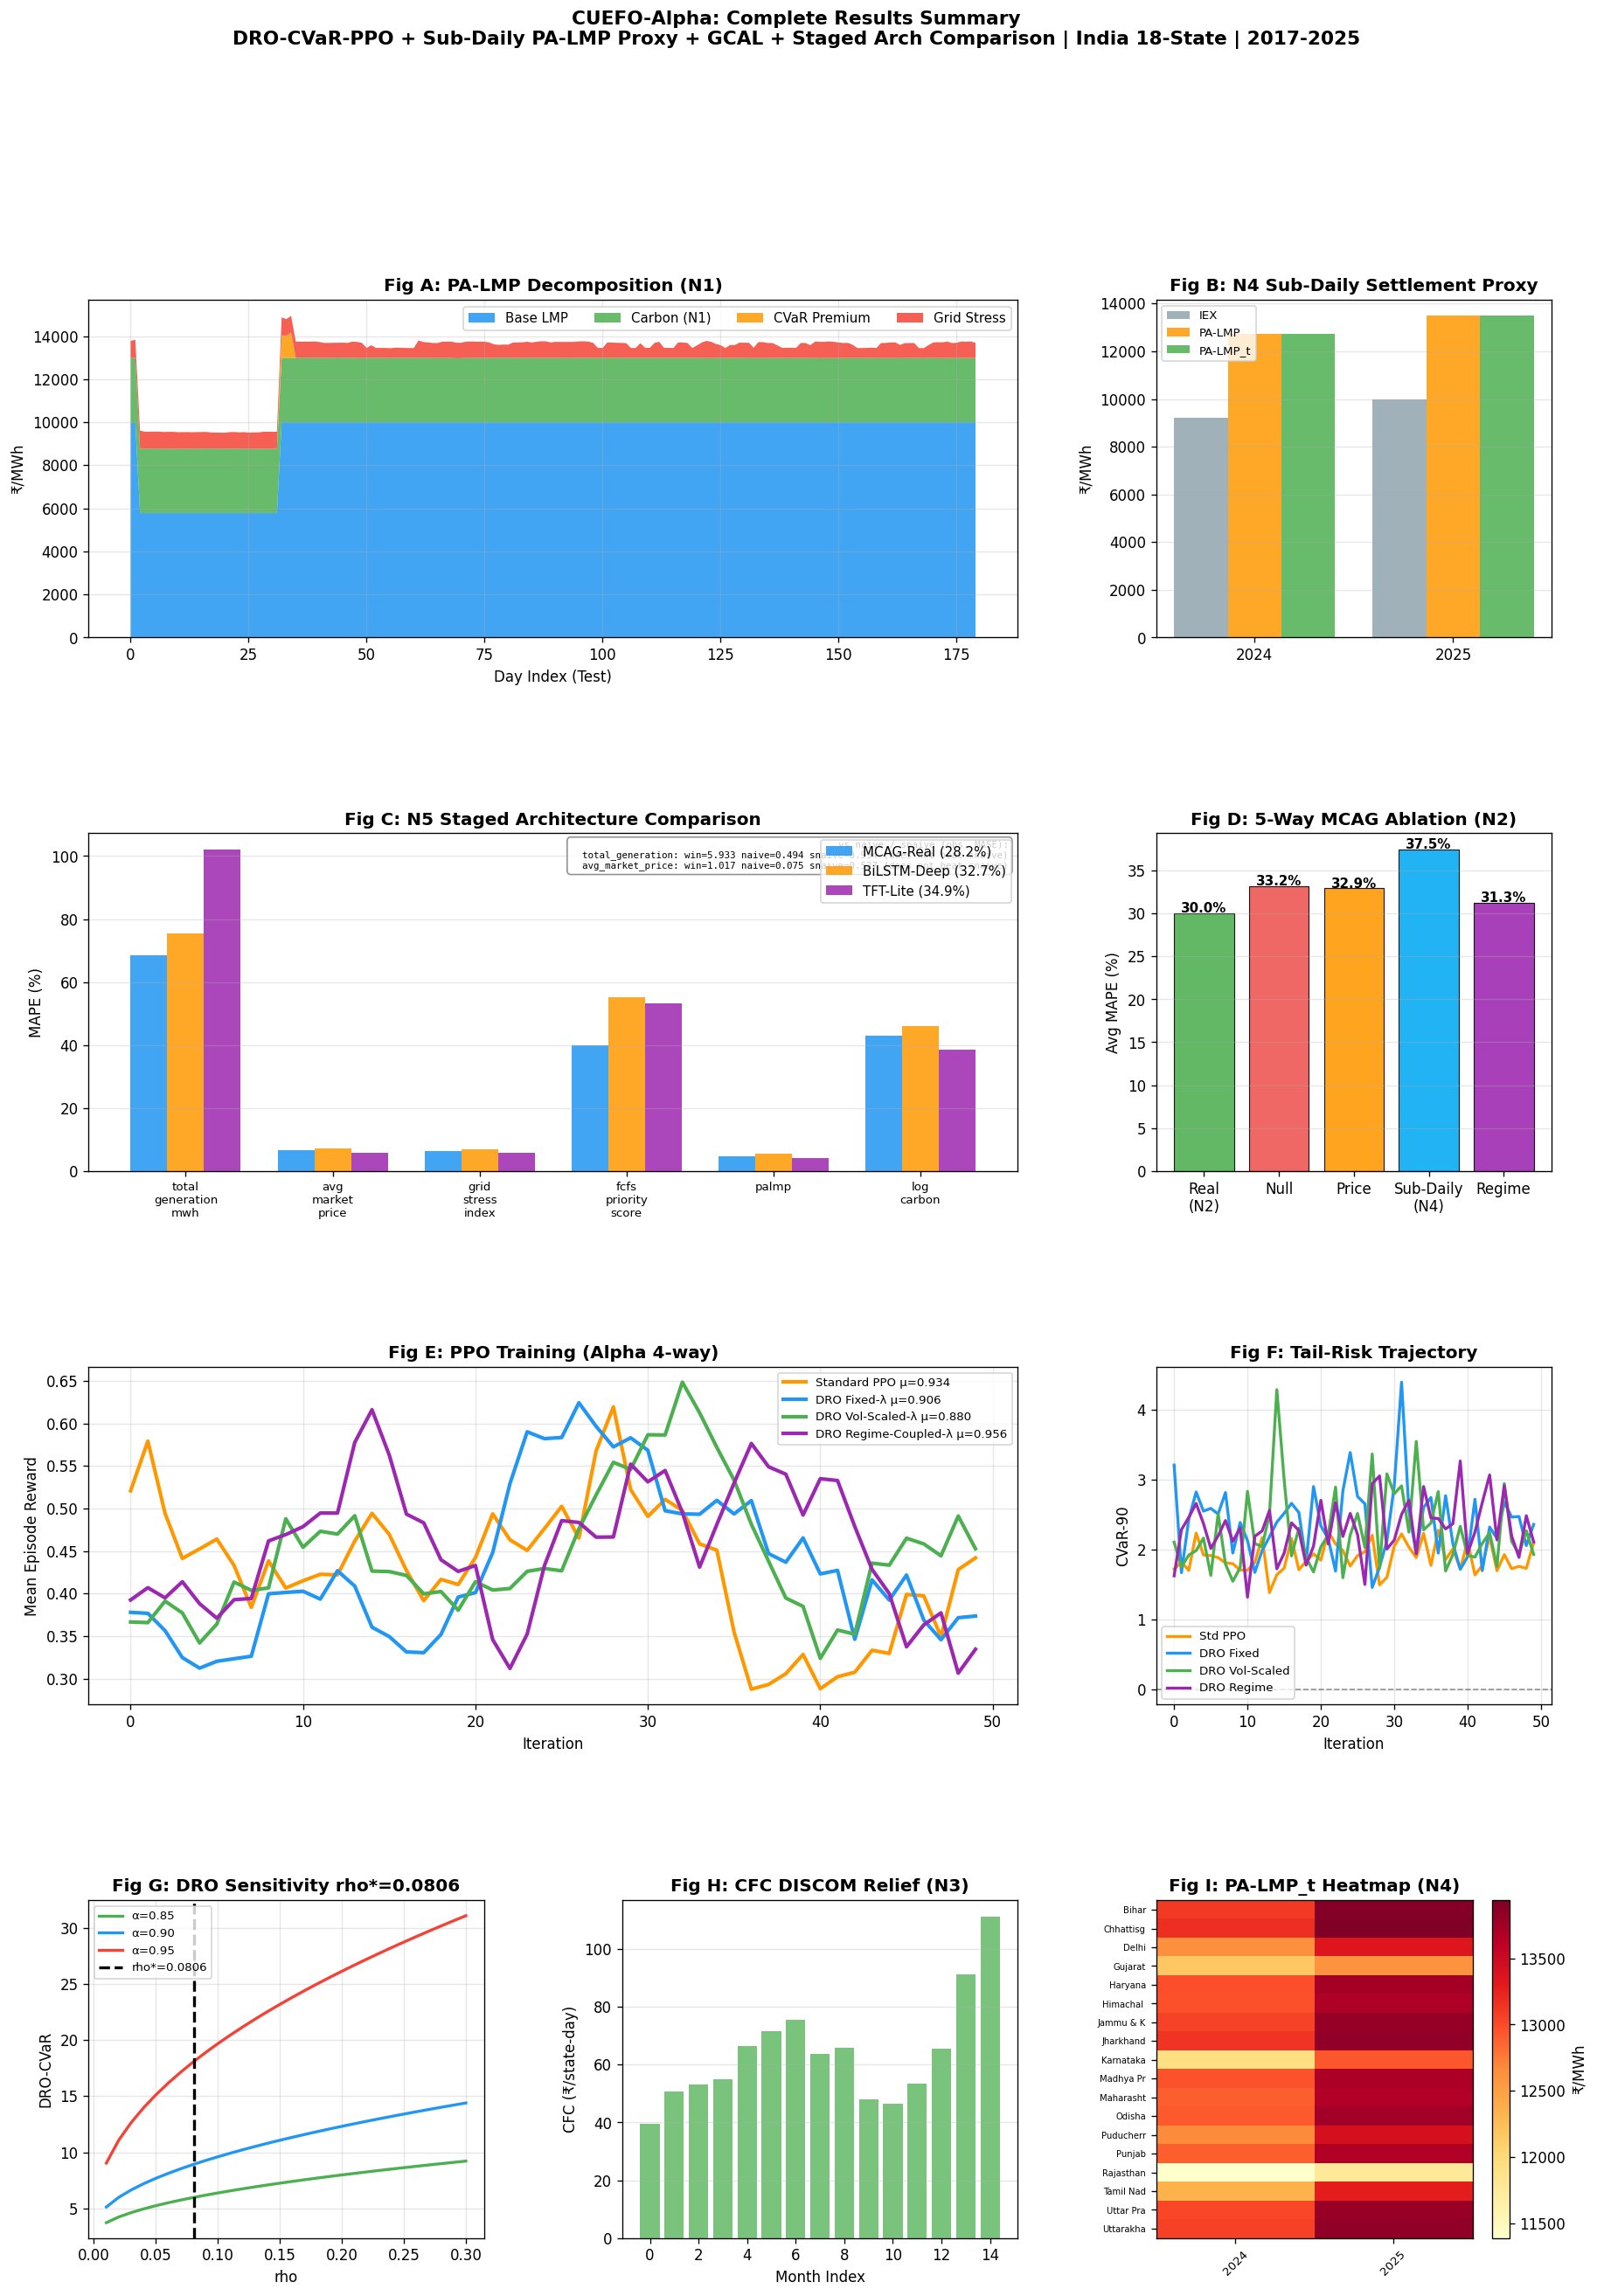

In [37]:
# ─── Cell 8.2 — Master Results Figure (Alpha 9-panel) ───────────────────────
fig=plt.figure(figsize=(18,24))
fig.suptitle('RE-FUSED-Alpha: Complete Results Summary\n'
             'DRO-CVaR-PPO + Sub-Daily PA-LMP Proxy + GCAL + Staged Arch Comparison | India 18-State | 2017-2025',
             fontsize=13,fontweight='bold',y=0.995)
gs=gridspec.GridSpec(4,3,figure=fig,hspace=0.58,wspace=0.35)

ax1=fig.add_subplot(gs[0,:2])
s=df_test.iloc[:180].reset_index(drop=True)
ax1.stackplot(range(len(s)),s['avg_market_price'],s['palmp_carbon_comp'],
              s['palmp_cvar_comp'],s['palmp_stress_comp'],
              labels=['Base LMP','Carbon (N1)','CVaR Premium','Grid Stress'],
              colors=['#2196F3','#4CAF50','#FF9800','#F44336'],alpha=0.85)
ax1.set_xlabel('Day Index (Test)'); ax1.set_ylabel('₹/MWh')
ax1.set_title('Fig A: PA-LMP Decomposition (N1)',fontweight='bold')
ax1.legend(ncol=4,fontsize=9); ax1.grid(True,alpha=0.3)

ax2=fig.add_subplot(gs[0,2])
by_y=df_test.groupby('year')[['avg_market_price','palmp','pa_lmp_t']].mean()
xb=np.arange(len(by_y)); wb=0.27
ax2.bar(xb-wb,by_y['avg_market_price'].values,wb,label='IEX',color='#90A4AE',alpha=0.85)
ax2.bar(xb,   by_y['palmp'].values,wb,            label='PA-LMP',color='#FF9800',alpha=0.85)
ax2.bar(xb+wb,by_y['pa_lmp_t'].values,wb,         label='PA-LMP_t',color='#4CAF50',alpha=0.85)
ax2.set_xticks(xb); ax2.set_xticklabels(by_y.index.astype(str))
ax2.set_ylabel('₹/MWh'); ax2.set_title('Fig B: N4 Sub-Daily Settlement Proxy',fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(True,alpha=0.3,axis='y')

ax3=fig.add_subplot(gs[1,:2])
x=np.arange(NT); w=0.25
ax3.bar(x-w,[best_ptst_r['per_target'][t]['MAPE'] for t in TARGETS],w,
        label=f"{best_ptst_name[:14]} ({best_ptst_r['avg_mape']:.1f}%)",color='#2196F3',alpha=0.85)
ax3.bar(x,  [best_bilstm_r['per_target'][t]['MAPE'] for t in TARGETS],w,
        label=f"{best_bilstm_name[:14]} ({best_bilstm_r['avg_mape']:.1f}%)",color='#FF9800',alpha=0.85)
ax3.bar(x+w,[best_tft_r['per_target'][t]['MAPE'] for t in TARGETS],w,
        label=f"{best_tft_name[:14]} ({best_tft_r['avg_mape']:.1f}%)",color='#9C27B0',alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels([t.replace('_','\n') for t in TARGETS],fontsize=8)
ax3.set_ylabel('MAPE (%)'); ax3.set_title('Fig C: N5 Staged Architecture Comparison',fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True,alpha=0.3,axis='y')

# -- Idea #7: overlay naive/snaive baseline anchor (obs. MASE) onto Fig C --
_bc3 = {k: v for k, v in S.get('baseline_comparison', {}).items() if k != '_source'}
if _bc3:
    _lines = ['vs naive / snaive (obs. MASE):']
    for _t, _v in _bc3.items():
        _mark = '(beats snaive)' if _v.get('beats_snaive') else '(does not beat snaive)'
        _lines.append(f"  {_t[:16]}: win={_v['winner_mase']:.3f} naive={_v['naive_mase']:.3f} snaive={_v['snaive_mase']:.3f} {_mark}")
    ax3.text(0.99,0.98,"\n".join(_lines),transform=ax3.transAxes,fontsize=6.5,
             va='top',ha='right',fontfamily='monospace',
             bbox=dict(boxstyle='round',facecolor='white',alpha=0.85,edgecolor='gray',pad=0.4))

ax4=fig.add_subplot(gs[1,2])
labels_abl=['Real\n(N2)','Null','Price','Sub-Daily\n(N4)','Regime']
vals_abl=[abl['real']['avg_mape'],abl['null']['avg_mape'],abl['price']['avg_mape'],
          abl['5min']['avg_mape'],abl['regime']['avg_mape']]
brs4=ax4.bar(labels_abl,vals_abl,color=['#4CAF50','#EF5350','#FF9800','#03A9F4','#9C27B0'],
             alpha=0.88,edgecolor='k',lw=0.7)
for b,v in zip(brs4,vals_abl):
    ax4.text(b.get_x()+b.get_width()/2,v+0.1,f'{v:.1f}%',ha='center',fontsize=9,fontweight='bold')
ax4.set_ylabel('Avg MAPE (%)'); ax4.set_title(f'Fig D: 5-Way MCAG Ablation (N2)',fontweight='bold')
ax4.grid(True,alpha=0.3,axis='y')

ax5=fig.add_subplot(gs[2,:2])
for res,col,lab in [(res_ppo,'#FF9800','Standard PPO'),
                    (res_dro,'#2196F3','DRO Fixed-λ'),
                    (res_dro_adp,'#4CAF50','DRO Vol-Scaled-λ'),
                    (res_dro_regime,'#9C27B0','DRO Regime-Coupled-λ')]:
    ax5.plot(ndimage.uniform_filter1d(res['rh'],8),color=col,lw=2.5,
             label=f"{lab} μ={res['mean_reward']:.3f}")
ax5.set_xlabel('Iteration'); ax5.set_ylabel('Mean Episode Reward')
ax5.set_title('Fig E: PPO Training (Alpha 4-way)',fontweight='bold')
ax5.legend(fontsize=8); ax5.grid(True,alpha=0.3)

ax6=fig.add_subplot(gs[2,2])
for res,col,lab in [(res_ppo,'#FF9800','Std PPO'),(res_dro,'#2196F3','DRO Fixed'),(res_dro_adp,'#4CAF50','DRO Vol-Scaled'),(res_dro_regime,'#9C27B0','DRO Regime')]:
    ax6.plot(res['cvh'],color=col,lw=2,label=lab)
ax6.axhline(0,color='k',ls='--',alpha=0.4,lw=1)
ax6.set_xlabel('Iteration'); ax6.set_ylabel('CVaR-90')
ax6.set_title('Fig F: Tail-Risk Trajectory',fontweight='bold')
ax6.legend(fontsize=8); ax6.grid(True,alpha=0.3)

ax7=fig.add_subplot(gs[3,0])
rhos_s=np.linspace(0.01,0.30,30); L2=np.random.default_rng(42).standard_t(df=3,size=500)
for a,col,lab in [(0.85,'#4CAF50','α=0.85'),(0.90,'#2196F3','α=0.90'),(0.95,'#F44336','α=0.95')]:
    k=max(1,int((1-a)*len(L2))); cv_b=np.sort(L2)[-k:].mean(); sig=np.sort(L2)[-k:].std()
    ax7.plot(rhos_s,[cv_b+np.sqrt(r)*sig/(1-a) for r in rhos_s],color=col,lw=2,label=lab)
ax7.axvline(RHO,color='k',ls='--',lw=2,label=f'rho*={RHO:.4f}')
ax7.set_xlabel('rho'); ax7.set_ylabel('DRO-CVaR')
ax7.set_title(f'Fig G: DRO Sensitivity rho*={RHO:.4f}',fontweight='bold')
ax7.legend(fontsize=8); ax7.grid(True,alpha=0.3)

ax8=fig.add_subplot(gs[3,1])
monthly_c=df_test.groupby(['year','month'])['cfc_value_inr'].mean().reset_index()
monthly_c['t']=range(len(monthly_c))
ax8.bar(monthly_c['t'],monthly_c['cfc_value_inr'],alpha=0.75,color='#4CAF50')
ax8.set_xlabel('Month Index'); ax8.set_ylabel('CFC (₹/state-day)')
ax8.set_title('Fig H: CFC DISCOM Relief (N3)',fontweight='bold'); ax8.grid(True,alpha=0.3,axis='y')

ax9=fig.add_subplot(gs[3,2])
pivot9=df_test.groupby(['state_name','year'])['pa_lmp_t'].mean().unstack(fill_value=0)
im9=ax9.imshow(pivot9.values,aspect='auto',cmap='YlOrRd')
ax9.set_yticks(range(len(pivot9.index))); ax9.set_yticklabels([s[:9] for s in pivot9.index],fontsize=6)
ax9.set_xticks(range(len(pivot9.columns))); ax9.set_xticklabels(pivot9.columns.astype(str),fontsize=8,rotation=45)
ax9.set_title('Fig I: PA-LMP_t Heatmap (N4)',fontweight='bold')
plt.colorbar(im9,ax=ax9,label='₹/MWh')

plt.savefig(OUT_DIR/'figures'/'REFUSED_Alpha_Master_Results.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print("Master figure saved: REFUSED_Alpha_Master_Results.png")
print(f"\nAll RE-FUSED-Alpha outputs in: {OUT_DIR}/")
